CWD          = /Users/adi/Desktop/EmergentRobotSelf/AnalysisScripts
REPO_ROOT     = /Users/adi/Desktop/EmergentRobotSelf
MODELS_DIR    = /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_7_2026-01-30_23-29-24/models | exists: True
ALL_STATES    = /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/StatesConcat/ALL_states_concat.npy | exists: True
[BATCH] Will compute caches for these models dirs:
  01. /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_7_2026-01-30_23-29-24/models

[BATCH] Run 1/1
[CACHE] Overwrite enabled -> clearing old cache:
  /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_7_2026-01-30_23-29-24/models/_module_explorer_cache

[RUN] WSJ_relu_7_2026-01-30_23-29-24
      models_dir: /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu/WSJ_relu_7_2026-01-30_23-29-24/models

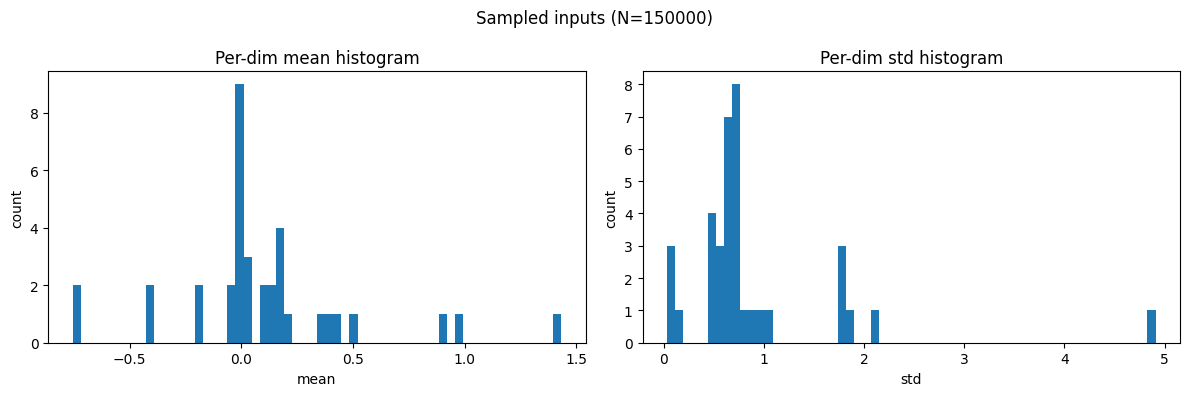

[STATES] input normalization disabled

--------------------------------------------------------------------------------
[SEQ] t=1/138  walk:c001_b01_walk_plateau_2026-01-31_00-42-18  refs=[c001_b02_spin_plateau_2026-01-31_02-06-00, c001_b03_jump_plateau_2026-01-31_02-52-46]

--------------------------------------------------------------------------------
[SEQ] t=2/138  spin:c001_b02_spin_plateau_2026-01-31_02-06-00  refs=[c001_b01_walk_plateau_2026-01-31_00-42-18, c001_b03_jump_plateau_2026-01-31_02-52-46]

--------------------------------------------------------------------------------
[SEQ] t=3/138  jump:c001_b03_jump_plateau_2026-01-31_02-52-46  refs=[c001_b02_spin_plateau_2026-01-31_02-06-00, c002_b01_walk_plateau_2026-01-31_04-07-51]

--------------------------------------------------------------------------------
[SEQ] t=4/138  walk:c002_b01_walk_plateau_2026-01-31_04-07-51  refs=[c001_b03_jump_plateau_2026-01-31_02-52-46, c002_b02_spin_plateau_2026-01-31_06-00-33]

-------------

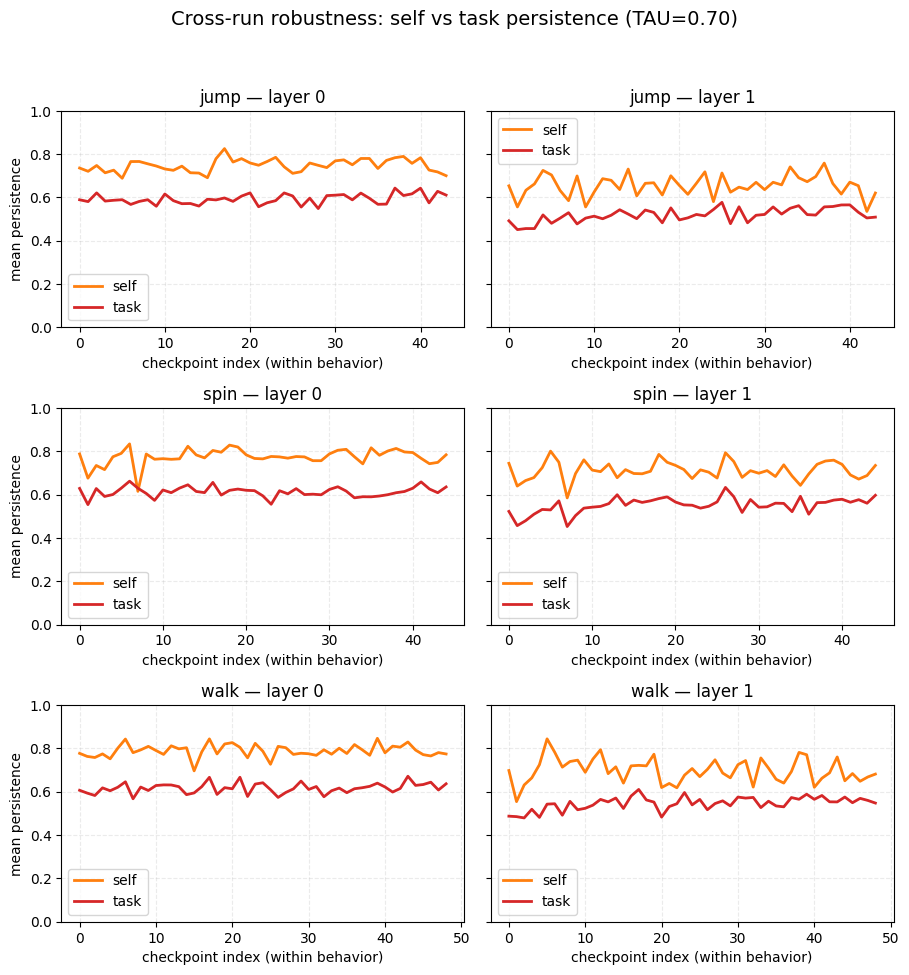

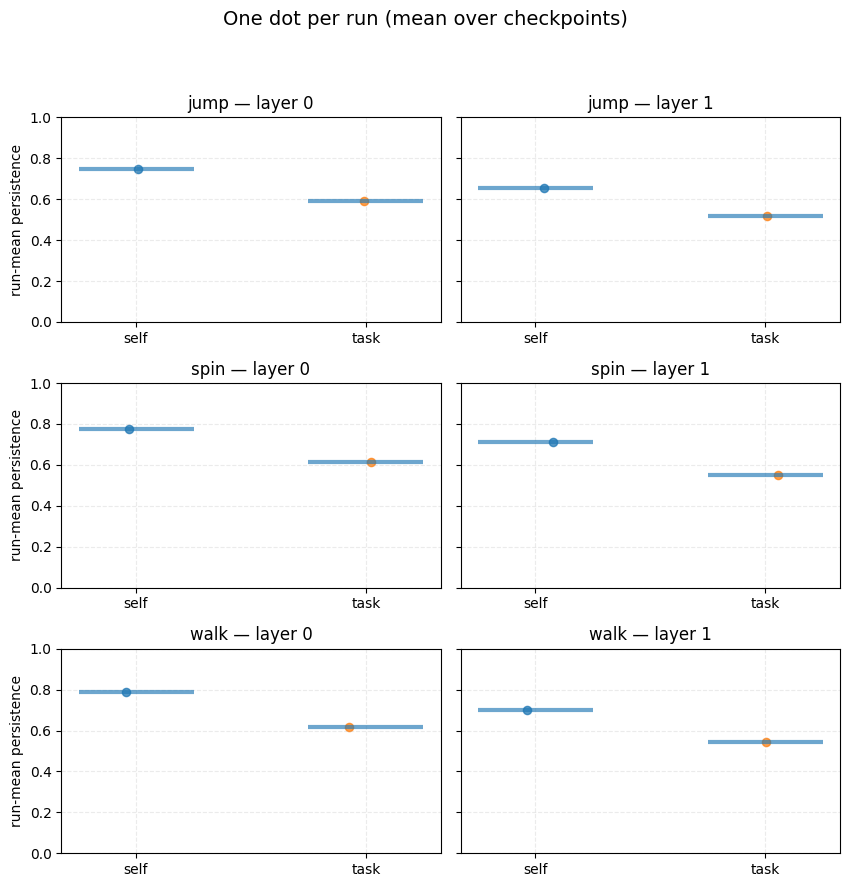

In [1]:
#!/usr/bin/env python3
from pathlib import Path

# =========================
# ========= CONFIG ========
# =========================

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

MODELS_DIR = (
    REPO_ROOT
    / "Checkpoints_States_selectedGraphs"
    / "WalkSpinJump_relu"
    / "WSJ_relu_7_2026-01-30_23-29-24/models"
).resolve()
# -------------------------
# MODE SELECT
# -------------------------
CACHE_XLSX_PATH = ""  # set to cache dir to LOAD; leave "" to COMPUTE

# -------------------------
# MULTI-RUN COMPUTE CONTROL
# -------------------------
MULTI_RUN_MODE = True
RUN_PATHS = [str(MODELS_DIR)]  # can be a models dir or a parent folder to search under
RECOMPUTE_OVERWRITE = True
CONTINUE_ON_RUN_ERROR = True
RUN_DISCOVERY_MAX_DEPTH = 2

# =========================
# === MODEL SOURCE CONFIG ===
# =========================
# MULTI_CYCLE_MODE=True means "discover checkpoints under model_dir / MODEL_PATH_LIST".
MULTI_CYCLE_MODE = True

# Used when MULTI_RUN_MODE=False
MODEL_DIR = str(MODELS_DIR)

# Leave empty to glob model_dir/*_for_play.pth
MODEL_PATH_LIST = ""

# If MULTI_CYCLE_MODE=False, provide explicit sequences.
SINGLE_BEHAVIOR_MODEL_PATHS = {}
SINGLE_SEQUENCE_ID = "single_seq"

# =========================
# === GLOBAL STATE POOL ===
# =========================
ALL_STATES_PATH = str(
    (REPO_ROOT / "Checkpoints_States_selectedGraphs" / "StatesConcat" / "ALL_states_concat.npy").resolve()
)

N_ALL_STATES = 150_000
PLOT_INPUTS_SUMMARY = True

ANALYZE_NORM_INPUTS = True
INPUT_NORM_MODE = "none"  # "zscore" or "none"

# --- Layers to analyze (hidden layers) ---
LAYER_INDICES = [0, 1]

SEED = 0
EPS = 1e-8
MIN_STD = 1e-5

ACTIVATION = "relu"  # {"elu","relu","tanh"}

# alive-only control
ALIVE_ONLY_CLUSTERING = True
ALIVE_ONLY_PLOTTING = True

# ---- Variant selector ----
# 1: signed R, natural order (blocks from |R| threshold graph)
# 2: |R| heatmaps, natural order (blocks from |R| threshold graph)
# 3: signed R, blocks ordered largest -> smallest (blocks from |R| threshold graph)
# 4: |R| heatmaps, blocks ordered largest -> smallest (blocks from |R| threshold graph)
# 5: signed R, blocks ordered largest -> smallest (blocks from |R| threshold graph)
VERSION = 3

CMAP = "RdBu_r"
VMIN, VCENTER, VMAX = -1.0, 0.0, 1.0

# =========================
# === NEW BLOCK-DIAGONALISATION CONFIG (ABS TAU + CC + RCM) ===
# =========================
# Keep edges where |R[i,j]| >= TAU, blocks are connected components, and ordering is:
#   blocks by size + RCM within each block.
TAU = 0.70
BD_MIN_BLOCK_SIZE = 1

# -------------------------
# CACHE OUTPUT CONTROL
# -------------------------
PLOT_CACHE_N_CYCLES = 10

# Condensed module summary:
# rank 1 = "self module" (largest block)
# rank 2 = "task module" (all other blocks merged)
TOPK_CLUSTERS_SUMMARY = 2

# --- Robust-loading / skip behavior ---
ALLOW_UNSAFE_TORCH_LOAD = True
SKIP_BAD_CYCLES = True
MIN_CKPT_BYTES = 0

DEVICE = "cpu"

# ---- quick sanity prints ----
print("CWD          =", Path.cwd().resolve())
print("REPO_ROOT     =", REPO_ROOT)
print("MODELS_DIR    =", MODELS_DIR, "| exists:", MODELS_DIR.is_dir())
print("ALL_STATES    =", ALL_STATES_PATH, "| exists:", Path(ALL_STATES_PATH).is_file())

# =========================
# ======== IMPORTS ========
# =========================

import os
import gc
import glob
import pickle
import shutil
import traceback

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components

try:
    import ipywidgets as widgets
except Exception:
    widgets = None

# =========================
# ======== HELPERS ========
# =========================

def _seed_everything(seed: int):
    import random
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def _torch_load_compat(path: str):
    if MIN_CKPT_BYTES and os.path.exists(path):
        try:
            sz = os.path.getsize(path)
            if sz < MIN_CKPT_BYTES:
                raise RuntimeError(f"Checkpoint too small ({sz} bytes) < MIN_CKPT_BYTES={MIN_CKPT_BYTES}")
        except OSError:
            pass

    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except (pickle.UnpicklingError, RuntimeError, EOFError, ValueError):
        if not ALLOW_UNSAFE_TORCH_LOAD:
            raise
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")

def _load_rlg_forplay_state_dict(path: str) -> dict:
    payload = _torch_load_compat(path)
    if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
        sd = {}
        for k, v in payload["model"].items():
            sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
        return sd
    raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

def _try_load_sd(path: str):
    try:
        sd = _load_rlg_forplay_state_dict(path)
        return sd, None
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"

def _discover_actor_mlp_layers(state_dict: dict):
    candidates = []
    for k in state_dict.keys():
        if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
            parts = k.split(".")
            try:
                idx = int(parts[-2])
                bias_key = k[:-6] + "bias"
                if bias_key in state_dict:
                    candidates.append((idx, k, bias_key))
            except Exception:
                candidates.append((10**6, k, k[:-6] + "bias"))
    candidates.sort(key=lambda t: (t[0], t[1]))
    return candidates

def _first_linear_in(actor_layers, sd):
    if not actor_layers:
        raise RuntimeError("No actor MLP layers found.")
    _, wkey, _ = actor_layers[0]
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    if W.ndim != 2:
        raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
    return W.shape[1], W.shape[0]  # in_dim, out_dim

def _activation(x: np.ndarray, name: str) -> np.ndarray:
    if name == "elu":
        y = x.copy()
        neg = x <= 0
        y[neg] = np.expm1(x[neg])
        return y
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "tanh":
        return np.tanh(x)
    raise ValueError(f"Unsupported ACTIVATION '{name}'")

def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    dead_idx = np.where(dead_mask)[0].astype(int)
    alive_idx = np.where(~dead_mask)[0].astype(int)
    return dead_idx, alive_idx

def corr_matrix(X):
    """
    Cosine-similarity matrix between columns of X.
    X: (T, N) activations. Returns (N, N), diag=1.
    """
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError("corr_matrix expects 2D array (T, N)")
    n = X.shape[1]
    if n == 0:
        return np.zeros((0, 0), np.float32)
    if n == 1:
        return np.ones((1, 1), np.float32)

    norms = np.linalg.norm(X, axis=0, keepdims=True).astype(np.float64)
    norms = np.where(norms < 1e-12, 1.0, norms)
    Xn = (X.astype(np.float64, copy=False) / norms)

    S = (Xn.T @ Xn)
    S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
    S = np.clip(S, -1.0, 1.0)

    np.fill_diagonal(S, 1.0)
    return S.astype(np.float32, copy=False)

def _cluster_bounds(labels, order):
    lr = labels[order]
    return [i - 0.5 for i in range(1, len(lr)) if lr[i] != lr[i - 1]]

def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)

    if A.size == 0 or B.size == 0:
        sim = np.zeros((A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0), dtype=np.float32)
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

    nA = np.linalg.norm(A, axis=0, keepdims=True)
    nB = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0

    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim)
    sim = np.clip(sim, -1.0, 1.0)

    i_idx, j_idx = linear_sum_assignment(-sim)
    matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals

def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name):
    outs = []
    h = X
    for _, wkey, bkey in actor_layers:
        W = sd[wkey]
        if isinstance(W, torch.Tensor):
            W = W.detach().cpu().numpy()
        b = sd[bkey]
        if isinstance(b, torch.Tensor):
            b = b.detach().cpu().numpy()
        h = h @ W.T + b[None, :]
        h = _activation(h, activation_name)
        outs.append(h.astype(np.float32, copy=False))
    return outs

def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
    X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
    outs = _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name)
    if layer_idx < 0 or layer_idx >= len(outs):
        raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
    return outs[layer_idx]

def _safe_corr(a, b, eps: float = 1e-8):
    """
    Absolute cosine similarity between 1D vectors a and b.
    """
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0:
        return 0.0

    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return 0.0

    c = float((a.astype(np.float64) @ b.astype(np.float64)) / (na * nb))
    if not np.isfinite(c):
        return 0.0
    c = max(-1.0, min(1.0, c))
    return float(abs(c))

def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return np.arange(0, dtype=int)
    if base_order is None:
        base_order = np.arange(n, dtype=int)
    base_order = np.asarray(base_order)
    unique_cids = np.unique(labels)
    sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]
    new_order_list = []
    labels_in_base = labels[base_order]
    for cid in sorted_cids:
        mask = (labels_in_base == cid)
        new_order_list.append(base_order[mask])
    new_order = np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)
    return new_order

def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)
    sorted_cids = unique_cids[order]
    cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    new_labels = np.array([cid_to_rank[c] for c in labels], dtype=int)
    return new_labels

def _evenly_spaced_indices(n, k):
    if k <= 0:
        return []
    if n <= k:
        return list(range(n))
    idxs = np.linspace(0, n - 1, k)
    idxs = np.unique(np.round(idxs).astype(int)).tolist()
    if len(idxs) < k:
        for i in range(n):
            if i not in idxs:
                idxs.append(i)
            if len(idxs) >= k:
                break
        idxs = sorted(idxs)[:k]
    return idxs

def _plot_inputs_summary(X: np.ndarray, title: str = "Sampled inputs"):
    mu = X.mean(axis=0)
    sd = X.std(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(mu, bins=60)
    axes[0].set_title("Per-dim mean histogram")
    axes[0].set_xlabel("mean")
    axes[0].set_ylabel("count")

    axes[1].hist(sd, bins=60)
    axes[1].set_title("Per-dim std histogram")
    axes[1].set_xlabel("std")
    axes[1].set_ylabel("count")

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

# =========================
# === NEW BLOCK DIAGONALISATION (ABS TAU + CC + RCM) ===
# =========================

def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
    """
    Keep edges where |cos|>=tau, blocks={connected components}, order=blocks by size + RCM inside.
    Returns:
      order (0-based), bd_ids (1-based)
    """
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    if n == 1:
        return np.array([0], dtype=int), np.array([1], dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")  # 0-based
    comp = comp0.copy()

    # merge tiny into a single "misc" block
    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=n_comp)
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep = [c for c in np.unique(comp) if c != -1]
            remap = {c: i for i, c in enumerate(keep)}
            comp2 = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp = comp2
            n_comp = int(comp.max()) + 1

    # order blocks by size; RCM inside each block
    sizes = [(c, int(np.sum(comp == c))) for c in range(n_comp)]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order = np.concatenate(parts).astype(int)
    bd_ids_1based = (comp + 1).astype(int)
    return order, bd_ids_1based

# =========================
# === MULTI-RUN IO ===
# =========================

def _looks_like_models_dir(d: str) -> bool:
    if not os.path.isdir(d):
        return False
    return len(glob.glob(os.path.join(d, "*_for_play.pth"))) > 0

def _resolve_models_dir(p: str) -> str | None:
    if not p:
        return None
    p = os.path.expanduser(os.path.expandvars(str(p).strip()))
    if not p:
        return None

    if os.path.isfile(p):
        d = os.path.dirname(p)
        if os.path.basename(d) == "models":
            return d
        if _looks_like_models_dir(d):
            return d
        return None

    if not os.path.isdir(p):
        return None

    base = os.path.basename(p)

    if base == "_module_explorer_cache":
        md = os.path.dirname(p)
        if os.path.basename(md) == "models":
            return md

    if base == "models":
        return p

    md = os.path.join(p, "models")
    if os.path.isdir(md):
        return md

    md2 = os.path.join(p, "organized", "models")
    if os.path.isdir(md2):
        return md2

    return None

def _discover_models_dirs_under_parent(parent: str, max_depth: int = 2):
    parent = os.path.expanduser(os.path.expandvars(str(parent).strip()))
    if not os.path.isdir(parent):
        return []

    found = set()
    parent_depth = parent.rstrip(os.sep).count(os.sep)

    for root, dirs, _ in os.walk(parent):
        depth = root.count(os.sep) - parent_depth
        if depth > max_depth:
            dirs[:] = []
            continue

        if os.path.basename(root) == "models":
            found.add(root)

        if "models" in dirs:
            found.add(os.path.join(root, "models"))

        if "organized" in dirs:
            cand = os.path.join(root, "organized", "models")
            if os.path.isdir(cand):
                found.add(cand)

    out = []
    for d in sorted(found):
        if _looks_like_models_dir(d):
            out.append(d)
    return out

def _expand_run_inputs(run_paths, max_depth=2):
    model_dirs = []
    for p in run_paths:
        p = os.path.expanduser(os.path.expandvars(str(p).strip()))
        if not p:
            continue
        md = _resolve_models_dir(p)
        if md is not None and _looks_like_models_dir(md):
            model_dirs.append(md)
            continue
        if os.path.isdir(p):
            model_dirs.extend(_discover_models_dirs_under_parent(p, max_depth=max_depth))
    return sorted(set(model_dirs))

def _clear_existing_cache(cache_root: str):
    if not os.path.isdir(cache_root):
        return

    for fn in [
        "phase_summary.csv",
        "plot_cache_index.csv",
        "module_explorer_cache.h5",
        "module_explorer_cache.xlsx",
    ]:
        fp = os.path.join(cache_root, fn)
        if os.path.exists(fp):
            try:
                os.remove(fp)
            except Exception:
                pass

    pc = os.path.join(cache_root, "plot_cache_npz")
    if os.path.isdir(pc):
        try:
            shutil.rmtree(pc)
        except Exception:
            pass

# =========================
# === GLOBAL STATES ===
# =========================

_STATES_CACHE = {}  # obs_dim -> dict(ref_inputs, combined_states)

def _get_ref_inputs_for_obs_dim(obs_dim: int):
    global _STATES_CACHE
    if obs_dim in _STATES_CACHE:
        return _STATES_CACHE[obs_dim]["ref_inputs"], _STATES_CACHE[obs_dim]["combined_states"]

    if not os.path.exists(ALL_STATES_PATH):
        raise FileNotFoundError(f"[states] missing: {ALL_STATES_PATH}")

    print(f"[STATES] Loading ALL states for obs_dim={obs_dim} ...")
    all_states = np.load(ALL_STATES_PATH)
    if all_states.ndim != 2 or all_states.shape[1] != obs_dim:
        raise ValueError(f"[states] {ALL_STATES_PATH} has shape {all_states.shape}, expected (*,{obs_dim})")

    n_avail = all_states.shape[0]
    if n_avail >= N_ALL_STATES:
        idx = np.random.choice(n_avail, size=N_ALL_STATES, replace=False)
        combined_states = all_states[idx].astype(np.float32, copy=False)
    else:
        idx = np.random.choice(n_avail, size=N_ALL_STATES, replace=True)
        combined_states = all_states[idx].astype(np.float32, copy=False)

    print(f"[STATES] loaded: {all_states.shape}, sampled: {combined_states.shape}")

    if PLOT_INPUTS_SUMMARY:
        _plot_inputs_summary(combined_states, title=f"Sampled inputs (N={N_ALL_STATES})")

    if ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore":
        mu_in = combined_states.mean(axis=0, keepdims=True)
        sd_in = combined_states.std(axis=0, keepdims=True)
        combined_states = (combined_states - mu_in) / (sd_in + 1e-8)
        print("[STATES] applied input z-score normalization")
    else:
        print("[STATES] input normalization disabled")

    ref_inputs = torch.as_tensor(combined_states, dtype=torch.float32, device=DEVICE)

    _STATES_CACHE[obs_dim] = {
        "ref_inputs": ref_inputs,
        "combined_states": combined_states,
    }
    return ref_inputs, combined_states

# =========================
# === DISCOVERY (GLOBAL ORDER) ===
# =========================

def _parse_ckpt_meta_from_filename(path: str):
    """
    Expected patterns:
      c038_b01_walk_..._for_play.pth
      c003_b02_spin_..._for_play.pth
      c003_b03_jump_..._for_play.pth

    Returns dict with:
      cycle_id, cycle_num, b_id, b_num, behavior, ckpt_id
    or None if unrecognized.
    """
    base = os.path.basename(path)
    if not base.endswith("_for_play.pth"):
        return None
    parts = base.split("_")
    if len(parts) < 3:
        return None

    cycle_id = parts[0]
    b_id = parts[1].lower()
    behavior = parts[2].lower()

    if behavior not in ("walk", "jump", "spin"):
        return None
    if not b_id.startswith("b"):
        return None

    cycle_digits = "".join(ch for ch in cycle_id if ch.isdigit())
    b_digits = "".join(ch for ch in b_id if ch.isdigit())
    cycle_num = int(cycle_digits) if cycle_digits else 0
    b_num = int(b_digits) if b_digits else 0

    ckpt_id = base[:-len("_for_play.pth")]

    return {
        "cycle_id": cycle_id,
        "cycle_num": cycle_num,
        "b_id": b_id,
        "b_num": b_num,
        "behavior": behavior,
        "ckpt_id": ckpt_id,
    }

def _discover_forplay_models_global(model_dir: str | None, model_path_list: str | None):
    """
    Returns:
      seq_all: list of dicts with keys:
        ckpt_id, cycle_id, behavior, path, global_idx, beh_seq_idx
      all_paths: sorted unique list
    """
    paths = []
    if model_path_list is not None and str(model_path_list).strip():
        for token in str(model_path_list).split():
            token = token.strip()
            if token.endswith("_for_play.pth"):
                paths.append(token)
    if model_dir is not None and str(model_dir).strip():
        pattern = os.path.join(str(model_dir), "*_for_play.pth")
        paths.extend(glob.glob(pattern))
    paths = sorted(set(paths))
    if not paths:
        raise RuntimeError("No *_for_play.pth models found from model_dir / MODEL_PATH_LIST.")

    items = []
    for p in paths:
        meta = _parse_ckpt_meta_from_filename(p)
        if meta is None:
            print(f"[warn] Skipping unrecognized filename: {os.path.basename(p)}")
            continue
        items.append({**meta, "path": p})

    if not items:
        raise RuntimeError("No recognized (walk/jump/spin) checkpoints found among *_for_play.pth files.")

    items.sort(key=lambda d: (d["cycle_num"], d["cycle_id"], d["b_num"], d["b_id"], os.path.basename(d["path"])))

    beh_counts = {}
    seq_all = []
    for gi, d in enumerate(items):
        beh = d["behavior"]
        beh_counts[beh] = beh_counts.get(beh, 0) + 1
        seq_all.append({
            "ckpt_id": d["ckpt_id"],
            "cycle_id": d["cycle_id"],
            "behavior": beh,
            "path": d["path"],
            "global_idx": int(gi),
            "beh_seq_idx": int(beh_counts[beh] - 1),
        })

    return seq_all, paths

def _infer_obs_dim_from_any_path(path_list):
    for p in path_list:
        if not os.path.exists(p):
            continue
        sd, _ = _try_load_sd(p)
        if sd is None:
            continue
        layers = _discover_actor_mlp_layers(sd)
        if not layers:
            continue
        obs_dim, _ = _first_linear_in(layers, sd)
        return obs_dim, p
    raise RuntimeError("Could not infer obs_dim: no loadable model found.")

# =========================
# === SINGLE-SEQUENCE MODE ===
# =========================

def _sequence_from_single_behavior_paths(single_paths_by_beh: dict, seq_id_prefix: str = "single"):
    order = ["walk", "spin", "jump"]
    flat = []
    for beh in order:
        if beh not in single_paths_by_beh:
            continue
        lst = single_paths_by_beh[beh]
        if not isinstance(lst, (list, tuple)) or len(lst) == 0:
            continue
        for i, p in enumerate(lst):
            p = os.path.expanduser(os.path.expandvars(str(p)))
            if not os.path.exists(p):
                raise FileNotFoundError(f"[single:{beh}] missing: {p}")
            flat.append({
                "ckpt_id": f"{seq_id_prefix}{i:04d}_{beh}",
                "cycle_id": f"{seq_id_prefix}{i:04d}",
                "behavior": beh,
                "path": p,
                "global_idx": len(flat),
                "beh_seq_idx": i,
            })
    if not flat:
        raise RuntimeError("SINGLE_BEHAVIOR_MODEL_PATHS is empty / invalid.")
    return flat

# =========================
# === CORE COMPUTE ===
# =========================

def _choose_reference_indices(n_total: int, t: int):
    if n_total <= 1:
        return []
    refs = []
    if t - 1 >= 0:
        refs.append(t - 1)
    if t + 1 < n_total:
        refs.append(t + 1)
    if len(refs) < 2:
        if t == 0 and t + 2 < n_total:
            refs.append(t + 2)
        if t == n_total - 1 and t - 2 >= 0:
            refs.append(t - 2)
    refs = sorted(set(refs), key=lambda j: (abs(j - t), j))
    return refs[:2]

def compute_cache_for_one_models_dir(model_dir: str, overwrite_cache: bool = True):
    """
    Computes block structure per checkpoint via NEW block-diagonalisation (abs tau + CC + RCM),
    and persistence scores by matching each checkpoint to up to two closest checkpoints in the global sequence order.

    Summary is condensed to:
      cluster_rank=1 -> self module (largest block)
      cluster_rank=2 -> task module (all other blocks merged)
    """
    if MULTI_CYCLE_MODE:
        if not str(model_dir).strip():
            raise RuntimeError("model_dir is empty (needed when MULTI_CYCLE_MODE=True).")
        model_dir = os.path.expanduser(os.path.expandvars(model_dir))
        if not os.path.isdir(model_dir):
            raise FileNotFoundError(f"model_dir not found: {model_dir}")

        run_root = os.path.dirname(model_dir)
        run_name = os.path.basename(run_root)

        seq_all, all_paths = _discover_forplay_models_global(model_dir, MODEL_PATH_LIST)
    else:
        seq_all = _sequence_from_single_behavior_paths(SINGLE_BEHAVIOR_MODEL_PATHS, seq_id_prefix=SINGLE_SEQUENCE_ID)
        any_path = seq_all[0]["path"]
        model_dir = os.path.dirname(os.path.expanduser(os.path.expandvars(any_path)))
        run_root = os.path.dirname(model_dir)
        run_name = os.path.basename(run_root) if run_root else "single_run"
        all_paths = [d["path"] for d in seq_all]

    cache_root = os.path.join(model_dir, "_module_explorer_cache")

    if overwrite_cache and os.path.isdir(cache_root):
        print(f"[CACHE] Overwrite enabled -> clearing old cache:\n  {cache_root}")
        _clear_existing_cache(cache_root)

    os.makedirs(cache_root, exist_ok=True)
    plot_cache_dir = os.path.join(cache_root, "plot_cache_npz")
    os.makedirs(plot_cache_dir, exist_ok=True)

    behaviors_present = sorted(set(d["behavior"] for d in seq_all))
    title_mode = "Persistence score (matched to two closest checkpoints)"

    print("\n" + "=" * 100)
    print(f"[RUN] {run_name}")
    print(f"      models_dir: {model_dir}")
    print(f"      cache_root: {cache_root}")
    print(f"      MULTI_CYCLE_MODE={MULTI_CYCLE_MODE}")
    print(f"      ALIVE_ONLY_CLUSTERING={ALIVE_ONLY_CLUSTERING}  ALIVE_ONLY_PLOTTING={ALIVE_ONLY_PLOTTING}")
    print(f"      MODE: {title_mode}")
    print(f"      checkpoints: {len(seq_all)}  behaviors: {behaviors_present}")
    print(f"      blockdiag: abs-tau + CC + RCM  |  TAU={TAU:.2f}  BD_MIN_BLOCK_SIZE={BD_MIN_BLOCK_SIZE}")
    print(f"      summary: rank1=self (largest block), rank2=task (all other blocks merged)")
    print("=" * 100)

    cached_global_idxs = set(_evenly_spaced_indices(len(seq_all), PLOT_CACHE_N_CYCLES))
    print(f"[CACHE] Plot-cache entries: {len(cached_global_idxs)} total.")

    obs_dim, obs_dim_src = _infer_obs_dim_from_any_path(all_paths)
    print(f"[INFO] Obs dim inferred from: {os.path.basename(obs_dim_src)}  -> {obs_dim}")

    ref_inputs, _ = _get_ref_inputs_for_obs_dim(obs_dim)

    phase_rows = []
    plot_index_rows = []
    skipped_items = []

    n_total = len(seq_all)

    for t in range(n_total):
        item_t = seq_all[t]
        ckpt_id = item_t["ckpt_id"]
        cycle_id = item_t["cycle_id"]
        beh = item_t["behavior"]
        beh_seq_idx = int(item_t["beh_seq_idx"])
        path_t = item_t["path"]

        ref_indices = _choose_reference_indices(n_total, t)
        ref_items = [seq_all[j] for j in ref_indices]
        ref_ids = [ri["ckpt_id"] for ri in ref_items]

        print("\n" + "-" * 80)
        if ref_ids:
            print(f"[SEQ] t={t+1}/{n_total}  {beh}:{ckpt_id}  refs=[{', '.join(ref_ids)}]")
        else:
            print(f"[SEQ] t={t+1}/{n_total}  {beh}:{ckpt_id}  refs=[]")

        if not os.path.exists(path_t):
            msg = f"missing file: {path_t}"
            print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        sd_t, err = _try_load_sd(path_t)
        if sd_t is None:
            msg = f"failed load: {os.path.basename(path_t)} | {err}"
            print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        layers_t = _discover_actor_mlp_layers(sd_t)
        if not layers_t:
            msg = f"no actor layers: {os.path.basename(path_t)}"
            print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        obs_dim_t, _ = _first_linear_in(layers_t, sd_t)
        if obs_dim_t != obs_dim:
            msg = f"obs_dim mismatch {obs_dim_t} vs global {obs_dim}"
            print(f"[warn] Skipping {beh}:{ckpt_id}: {msg}")
            skipped_items.append((beh, ckpt_id, msg))
            if SKIP_BAD_CYCLES:
                continue
            raise RuntimeError(msg)

        refs_loaded = []
        for rj, ref_it in zip(ref_indices, ref_items):
            sd_r, errr = _try_load_sd(ref_it["path"])
            if sd_r is None:
                print(f"[warn] Ref load failed: {os.path.basename(ref_it['path'])} | {errr}")
                continue
            layers_r = _discover_actor_mlp_layers(sd_r)
            if not layers_r:
                print(f"[warn] Ref has no actor layers: {os.path.basename(ref_it['path'])}")
                continue
            obs_dim_r, _ = _first_linear_in(layers_r, sd_r)
            if obs_dim_r != obs_dim:
                print(f"[warn] Ref obs_dim mismatch {obs_dim_r} vs global {obs_dim}; skipping ref")
                continue
            refs_loaded.append((rj, ref_it, sd_r, layers_r))

        for layer_idx in LAYER_INDICES:
            acts_full_t = get_layer_output_batch_from_ckpt(sd_t, ref_inputs, layer_idx, layers_t, ACTIVATION)
            total_n_t = int(acts_full_t.shape[1])

            dead_idx_t, alive_idx_t = _dead_alive_indices(acts_full_t, MIN_STD)
            dead_count_t = int(dead_idx_t.size)
            alive_count_t = int(alive_idx_t.size)

            if ALIVE_ONLY_CLUSTERING:
                acts_use_t = acts_full_t[:, alive_idx_t] if alive_idx_t.size else acts_full_t[:, :0]
            else:
                acts_use_t = acts_full_t

            A_z_t = _zscore_cols(acts_use_t, eps=EPS) if acts_use_t.size else acts_use_t.astype(np.float32, copy=False)
            R_signed_t = corr_matrix(A_z_t)

            _, wkey_curr, _ = layers_t[layer_idx]
            W_curr = sd_t[wkey_curr]
            if isinstance(W_curr, torch.Tensor):
                W_curr = W_curr.detach().cpu().numpy()
            else:
                W_curr = np.asarray(W_curr)
            imp_full_t = np.linalg.norm(W_curr, axis=1).astype(np.float32)
            if ALIVE_ONLY_PLOTTING:
                imp_use_t = imp_full_t[alive_idx_t] if alive_idx_t.size else imp_full_t[:0]
            else:
                imp_use_t = imp_full_t

            # ----- NEW BLOCK DIAGONALISATION (abs tau + CC + RCM) -----
            R_abs_t = np.abs(R_signed_t)
            order_t, labels_t = blockdiag_rcm_blocks_from_abs(
                R_abs_t,
                tau=TAU,
                min_block_size=BD_MIN_BLOCK_SIZE
            )
            labels_t = _relabel_clusters_by_size(labels_t)
            if VERSION in (3, 4, 5):
                order_t = _order_by_cluster_size(labels_t, base_order=order_t)
            K_best_t = int(np.max(labels_t)) if labels_t.size else 0

            # ----- persistence vs up to two closest checkpoints -----
            n_alive_t = int(R_signed_t.shape[0])
            act_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)
            conn_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)
            persistence_by_neuron = np.full(n_alive_t, np.nan, dtype=np.float32)

            if n_alive_t > 0 and len(refs_loaded) > 0:
                sum_act = np.zeros(n_alive_t, dtype=np.float64)
                sum_con = np.zeros(n_alive_t, dtype=np.float64)
                cnt = np.zeros(n_alive_t, dtype=np.int32)

                for _, ref_it, sd_r, layers_r in refs_loaded:
                    acts_full_r = get_layer_output_batch_from_ckpt(sd_r, ref_inputs, layer_idx, layers_r, ACTIVATION)
                    _, alive_idx_r = _dead_alive_indices(acts_full_r, MIN_STD)

                    if ALIVE_ONLY_CLUSTERING:
                        acts_use_r = acts_full_r[:, alive_idx_r] if alive_idx_r.size else acts_full_r[:, :0]
                    else:
                        acts_use_r = acts_full_r

                    A_z_r = _zscore_cols(acts_use_r, eps=EPS) if acts_use_r.size else acts_use_r.astype(np.float32, copy=False)
                    R_signed_r = corr_matrix(A_z_r)

                    _, i_idx, j_idx, _ = hungarian_match_cosine(A_z_t, A_z_r)
                    if i_idx.size:
                        i_idx = i_idx.astype(int, copy=False)
                        j_idx = j_idx.astype(int, copy=False)

                        Rt = R_signed_t[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
                        Rr = R_signed_r[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
                        np.fill_diagonal(Rt, 0.0)
                        np.fill_diagonal(Rr, 0.0)

                        dot = np.sum(Rt.astype(np.float64) * Rr.astype(np.float64), axis=1)
                        den = (
                            np.linalg.norm(Rt, axis=1).astype(np.float64)
                            * np.linalg.norm(Rr, axis=1).astype(np.float64)
                            + EPS
                        )
                        conn_row = np.abs(dot / den).astype(np.float32, copy=False)

                        for p, (it, jr) in enumerate(zip(i_idx, j_idx)):
                            a = float(_safe_corr(A_z_t[:, it], A_z_r[:, jr]))
                            c = float(conn_row[p])
                            if np.isfinite(a) and np.isfinite(c):
                                sum_act[it] += a
                                sum_con[it] += c
                                cnt[it] += 1

                    del acts_full_r
                    gc.collect()

                mask = cnt > 0
                if np.any(mask):
                    act_by_neuron[mask] = (sum_act[mask] / cnt[mask]).astype(np.float32)
                    conn_by_neuron[mask] = (sum_con[mask] / cnt[mask]).astype(np.float32)
                    persistence_by_neuron[mask] = 0.5 * (act_by_neuron[mask] + conn_by_neuron[mask])

            n_families = int(np.sum(np.isfinite(persistence_by_neuron)))
            labels_full = np.asarray(labels_t, dtype=int)

            # ----- CONDENSE MODULES: self (largest block) vs task (all others) -----
            self_mask = (labels_full == 1) if labels_full.size else np.zeros((n_alive_t,), dtype=bool)
            task_mask = (labels_full != 1) if labels_full.size else np.zeros((n_alive_t,), dtype=bool)

            # rank 1: self
            size_self_alive = int(np.sum(self_mask)) if self_mask.size else 0
            mean_act_self = float(np.nanmean(act_by_neuron[self_mask])) if np.any(self_mask) else np.nan
            mean_conn_self = float(np.nanmean(conn_by_neuron[self_mask])) if np.any(self_mask) else np.nan
            mean_pers_self = float(np.nanmean(persistence_by_neuron[self_mask])) if np.any(self_mask) else np.nan

            phase_rows.append({
                "run_name": run_name,
                "models_dir": model_dir,
                "behavior": beh,
                "cycle_id": cycle_id,
                "seq_id": ckpt_id,
                "seq_idx": int(beh_seq_idx),
                "global_idx": int(t),
                "ref_seq_id_1": str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                "ref_seq_id_2": str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                "n_ref_models": int(len(refs_loaded)),
                "layer_idx": int(layer_idx),
                "cluster_rank": 1,
                "cluster_size_neurons": int(size_self_alive),
                "mean_activation_stability": mean_act_self,
                "mean_connectivity_stability": mean_conn_self,
                "mean_persistence_score": mean_pers_self,
                "n_units": int(total_n_t),
                "n_alive_units": int(alive_count_t),
                "dead_units": int(dead_count_t),
                "n_families": int(n_families),
                "K_best": int(K_best_t),
                "states_path": ALL_STATES_PATH,
                "n_states_sampled": int(N_ALL_STATES),
                "analyze_norm_inputs": bool(ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore"),
                "input_norm_mode": str(INPUT_NORM_MODE),
                "title_mode": str(title_mode),
                "module_name": "self",
            })

            # rank 2: task (all other blocks merged)
            size_task_alive = int(np.sum(task_mask)) if task_mask.size else 0
            mean_act_task = float(np.nanmean(act_by_neuron[task_mask])) if np.any(task_mask) else np.nan
            mean_conn_task = float(np.nanmean(conn_by_neuron[task_mask])) if np.any(task_mask) else np.nan
            mean_pers_task = float(np.nanmean(persistence_by_neuron[task_mask])) if np.any(task_mask) else np.nan

            phase_rows.append({
                "run_name": run_name,
                "models_dir": model_dir,
                "behavior": beh,
                "cycle_id": cycle_id,
                "seq_id": ckpt_id,
                "seq_idx": int(beh_seq_idx),
                "global_idx": int(t),
                "ref_seq_id_1": str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                "ref_seq_id_2": str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                "n_ref_models": int(len(refs_loaded)),
                "layer_idx": int(layer_idx),
                "cluster_rank": 2,
                "cluster_size_neurons": int(size_task_alive),
                "mean_activation_stability": mean_act_task,
                "mean_connectivity_stability": mean_conn_task,
                "mean_persistence_score": mean_pers_task,
                "n_units": int(total_n_t),
                "n_alive_units": int(alive_count_t),
                "dead_units": int(dead_count_t),
                "n_families": int(n_families),
                "K_best": int(K_best_t),
                "states_path": ALL_STATES_PATH,
                "n_states_sampled": int(N_ALL_STATES),
                "analyze_norm_inputs": bool(ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore"),
                "input_norm_mode": str(INPUT_NORM_MODE),
                "title_mode": str(title_mode),
                "module_name": "task",
            })

            if t in cached_global_idxs:
                npz_name = f"{beh}__{ckpt_id}__layer{layer_idx}_plotcache.npz"
                npz_path = os.path.join(plot_cache_dir, npz_name)

                np.savez_compressed(
                    npz_path,
                    behavior=str(beh),
                    cycle_id=str(cycle_id),
                    seq_id=str(ckpt_id),
                    seq_idx=int(beh_seq_idx),
                    global_idx=int(t),
                    ref_seq_id_1=str(ref_ids[0]) if len(ref_ids) >= 1 else "",
                    ref_seq_id_2=str(ref_ids[1]) if len(ref_ids) >= 2 else "",
                    n_ref_models=int(len(refs_loaded)),
                    layer_idx=int(layer_idx),
                    R_signed_t=R_signed_t.astype(np.float32, copy=False),
                    order_t=order_t.astype(int, copy=False),
                    labels_t=labels_t.astype(int, copy=False),
                    alive_idx_t=alive_idx_t.astype(int, copy=False),
                    importance_t=imp_use_t.astype(np.float32, copy=False),
                    persistence_by_neuron=persistence_by_neuron.astype(np.float32, copy=False),
                    act_by_neuron=act_by_neuron.astype(np.float32, copy=False),
                    conn_by_neuron=conn_by_neuron.astype(np.float32, copy=False),
                    total_n_t=int(total_n_t),
                    alive_count_t=int(alive_count_t),
                    dead_count_t=int(dead_count_t),
                    K_best_t=int(K_best_t),
                    states_path=str(ALL_STATES_PATH),
                    n_states_sampled=int(N_ALL_STATES),
                    analyze_norm_inputs=bool(ANALYZE_NORM_INPUTS and INPUT_NORM_MODE == "zscore"),
                    input_norm_mode=str(INPUT_NORM_MODE),
                    title_mode=str(title_mode),
                    version=int(VERSION),
                    tau=float(TAU),
                    bd_min_block_size=int(BD_MIN_BLOCK_SIZE),
                )

                plot_index_rows.append({
                    "run_name": run_name,
                    "models_dir": model_dir,
                    "behavior": beh,
                    "seq_id": ckpt_id,
                    "seq_idx": int(beh_seq_idx),
                    "global_idx": int(t),
                    "layer_idx": int(layer_idx),
                    "npz_path": os.path.relpath(npz_path, start=cache_root),
                })

            del acts_full_t
            gc.collect()

        gc.collect()

    df_phase = pd.DataFrame(phase_rows)
    df_idx = pd.DataFrame(plot_index_rows)

    cache_phase_csv = os.path.join(cache_root, "phase_summary.csv")
    cache_idx_csv = os.path.join(cache_root, "plot_cache_index.csv")
    df_phase.to_csv(cache_phase_csv, index=False)
    df_idx.to_csv(cache_idx_csv, index=False)

    cache_h5_path = os.path.join(cache_root, "module_explorer_cache.h5")
    try:
        df_phase.to_hdf(cache_h5_path, key="phase_summary", mode="w", format="table", data_columns=True)
        df_idx.to_hdf(cache_h5_path, key="plot_cache_index", mode="a", format="table", data_columns=True)
        h5_msg = f"[DONE] Wrote HDF5 cache: {cache_h5_path}"
    except Exception as e:
        h5_msg = f"[warn] HDF5 save failed ({type(e).__name__}: {e}) — CSVs already written."

    print("\n" + "-" * 80)
    print(f"[DONE] Wrote CSV cache:\n  {cache_phase_csv}\n  {cache_idx_csv}")
    print(f"[DONE] Plot-cache npz folder:\n  {plot_cache_dir}")
    print(h5_msg)

    if skipped_items:
        print("\n[INFO] Skipped items:")
        for beh, sid, reason in skipped_items:
            print(f"  - {beh}:{sid}: {reason}")

    print(f"\nTo reload this run later without recompute, set:")
    print(f'  CACHE_XLSX_PATH = r"{cache_root}"')

    return {
        "run_name": run_name,
        "models_dir": model_dir,
        "cache_root": cache_root,
        "behaviors": behaviors_present,
        "n_checkpoints_total": int(len(seq_all)),
        "n_items_skipped": int(len(skipped_items)),
        "n_rows_phase": int(len(df_phase)),
        "n_rows_idx": int(len(df_idx)),
    }

# =========================
# === CROSS-RUN ROBUSTNESS (load multiple caches and aggregate) ===
# =========================

def _load_phase_from_cache_root(cache_root: str) -> pd.DataFrame:
    phase_csv = os.path.join(cache_root, "phase_summary.csv")
    if not os.path.exists(phase_csv):
        raise FileNotFoundError(f"phase_summary.csv missing in cache_root: {cache_root}")
    df = pd.read_csv(phase_csv)
    if "mean_persistence_score" not in df.columns and "mean_self_score" in df.columns:
        df["mean_persistence_score"] = df["mean_self_score"].astype(float)
    return df

def plot_cross_run_robustness(df_all: pd.DataFrame):
    """
    Aggregated robustness plots across runs:
      (A) mean ± std over runs for self vs task persistence across seq_idx
      (B) run-level dot distribution (one dot per run) for self vs task
    """
    if df_all is None or len(df_all) == 0:
        print("[ROBUST] No data to plot.")
        return

    if "cluster_rank" not in df_all.columns:
        print("[ROBUST] Missing cluster_rank in df; cannot plot.")
        return

    # We only care about rank 1/2 (self/task) in this condensed script
    df = df_all[df_all["cluster_rank"].isin([1, 2])].copy()

    behaviors = sorted(df["behavior"].unique().tolist())
    layers = sorted(df["layer_idx"].unique().tolist())

    # -------- (A) time-series mean ± std --------
    nrows = max(1, len(behaviors))
    ncols = max(1, len(layers))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.3 * nrows), sharex=False, sharey=True)
    axes = np.atleast_2d(axes)

    for r, beh in enumerate(behaviors):
        for c, L in enumerate(layers):
            ax = axes[r, c]
            sub = df[(df["behavior"] == beh) & (df["layer_idx"] == L)]

            if len(sub) == 0:
                ax.axis("off")
                continue

            # build aligned seq_idx grid
            max_seq = int(sub["seq_idx"].max()) if len(sub) else -1
            x = np.arange(max_seq + 1, dtype=int) if max_seq >= 0 else np.array([], dtype=int)
            if x.size == 0:
                ax.axis("off")
                continue

            for rank, name, alpha in [(1, "self", 0.25), (2, "task", 0.25)]:
                sub_rt = sub[sub["cluster_rank"] == rank]
                if len(sub_rt) == 0:
                    continue

                # run x seq table (values = mean_persistence_score)
                runs = sorted(sub_rt["run_name"].unique().tolist())
                Y = np.full((len(runs), len(x)), np.nan, dtype=float)
                for i, rn in enumerate(runs):
                    s = sub_rt[sub_rt["run_name"] == rn][["seq_idx", "mean_persistence_score"]].dropna()
                    if len(s) == 0:
                        continue
                    idxs = s["seq_idx"].to_numpy(dtype=int)
                    vals = s["mean_persistence_score"].to_numpy(dtype=float)
                    ok = (idxs >= 0) & (idxs < len(x))
                    Y[i, idxs[ok]] = vals[ok]

                mu = np.nanmean(Y, axis=0)
                sd = np.nanstd(Y, axis=0)

                # individual runs (light)
                for i in range(Y.shape[0]):
                    ax.plot(x, Y[i], alpha=0.12)

                ax.plot(x, mu, label=f"{name}", linewidth=2.0)
                ax.fill_between(x, mu - sd, mu + sd, alpha=alpha)

            ax.set_title(f"{beh} — layer {L}")
            ax.set_xlabel("checkpoint index (within behavior)")
            if c == 0:
                ax.set_ylabel("mean persistence")
            ax.set_ylim(0.0, 1.0)
            ax.grid(True, alpha=0.25, linestyle="--")
            ax.legend()

    fig.suptitle(f"Cross-run robustness: self vs task persistence (TAU={TAU:.2f})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # -------- (B) dot distribution: one dot per run --------
    # per run: average over all seq_idx for each (behavior, layer, module)
    df_run = (
        df.groupby(["run_name", "behavior", "layer_idx", "cluster_rank"], as_index=False)["mean_persistence_score"]
        .mean()
        .rename(columns={"mean_persistence_score": "run_mean_persistence"})
    )

    behaviors = sorted(df_run["behavior"].unique().tolist())
    layers = sorted(df_run["layer_idx"].unique().tolist())

    fig, axes = plt.subplots(len(behaviors), len(layers), figsize=(4.3 * len(layers), 3.0 * len(behaviors)), sharey=True)
    axes = np.atleast_2d(axes)

    rng = np.random.default_rng(0)
    for r, beh in enumerate(behaviors):
        for c, L in enumerate(layers):
            ax = axes[r, c]
            sub = df_run[(df_run["behavior"] == beh) & (df_run["layer_idx"] == L)]
            if len(sub) == 0:
                ax.axis("off")
                continue

            # x=0 self, x=1 task with jitter
            for rank, x0, label in [(1, 0.0, "self"), (2, 1.0, "task")]:
                vals = sub[sub["cluster_rank"] == rank]["run_mean_persistence"].to_numpy(dtype=float)
                if vals.size == 0:
                    continue
                jitter = rng.normal(loc=0.0, scale=0.06, size=vals.size)
                ax.scatter(np.full(vals.size, x0) + jitter, vals, s=35, alpha=0.75)

                if np.isfinite(vals).any():
                    ax.hlines(float(np.nanmean(vals)), x0 - 0.25, x0 + 0.25, linewidth=3.0, alpha=0.65)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["self", "task"])
            ax.set_ylim(0.0, 1.0)
            ax.grid(True, alpha=0.25, linestyle="--")
            ax.set_title(f"{beh} — layer {L}")

            if c == 0:
                ax.set_ylabel("run-mean persistence")

    fig.suptitle("One dot per run (mean over checkpoints)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

# =========================
# ========= MAIN ==========
# =========================

_seed_everything(SEED)

if str(CACHE_XLSX_PATH).strip():
    cache_root = os.path.expanduser(os.path.expandvars(str(CACHE_XLSX_PATH).strip()))
    if not os.path.isdir(cache_root):
        cache_root = os.path.dirname(cache_root)

    phase_csv = os.path.join(cache_root, "phase_summary.csv")
    idx_csv = os.path.join(cache_root, "plot_cache_index.csv")

    if not (os.path.exists(phase_csv) and os.path.exists(idx_csv)):
        raise FileNotFoundError(f"Cache CSVs missing.\nExpected:\n  {phase_csv}\n  {idx_csv}")

    df_phase = pd.read_csv(phase_csv)
    df_idx = pd.read_csv(idx_csv)

    if len(df_phase) == 0:
        raise RuntimeError("phase_summary is empty in the cache.")

    if "mean_persistence_score" not in df_phase.columns and "mean_self_score" in df_phase.columns:
        df_phase["mean_persistence_score"] = df_phase["mean_self_score"].astype(float)

    layers_to_plot = sorted(df_phase["layer_idx"].unique().tolist())
    behaviors_to_plot = sorted(df_phase["behavior"].unique().tolist())
    title_mode = str(df_phase["title_mode"].iloc[0]) if "title_mode" in df_phase.columns else "Persistence score"

    print(f"[CACHE] layers_to_plot={layers_to_plot}")
    print(f"[CACHE] behaviors={behaviors_to_plot}")
    print(f"[CACHE] mode={title_mode}")

    def _series_for(beh, layer_idx, rank, col):
        sub = df_phase[
            (df_phase["behavior"] == beh) &
            (df_phase["layer_idx"] == layer_idx) &
            (df_phase["cluster_rank"] == rank)
        ][["seq_idx", col]].sort_values("seq_idx")
        max_step = int(sub["seq_idx"].max()) if len(sub) else -1
        if max_step < 0:
            return np.array([], dtype=float), np.array([], dtype=float)
        idx = np.arange(max_step + 1, dtype=int)
        arr = np.full(len(idx), np.nan, dtype=float)
        arr[sub["seq_idx"].to_numpy(dtype=int)] = sub[col].to_numpy(dtype=float)
        return idx, arr

    def plot_phase_summary(rank1=1, rank2=2):
        for beh in behaviors_to_plot:
            plt.figure(figsize=(9, 4))
            for i, L in enumerate(layers_to_plot):
                c = f"C{i % 10}"
                x1, y1 = _series_for(beh, L, rank1, "cluster_size_neurons")
                x2, y2 = _series_for(beh, L, rank2, "cluster_size_neurons")
                if x1.size:
                    plt.plot(x1, y1, label=f"{beh} Layer {L} — self size", color=c)
                if x2.size:
                    plt.plot(x2, y2, label=f"{beh} Layer {L} — task size", color=c, alpha=0.25)
            plt.xlabel("Checkpoint index (within behavior)")
            plt.ylabel("Module size (alive neurons)")
            plt.title(f"Self vs Task module size vs checkpoint — {beh}\n{title_mode}")
            plt.grid(True, alpha=0.3, linestyle="--")
            plt.legend()
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(9, 4))
            for i, L in enumerate(layers_to_plot):
                c = f"C{i % 10}"
                x1, y1 = _series_for(beh, L, rank1, "mean_persistence_score")
                x2, y2 = _series_for(beh, L, rank2, "mean_persistence_score")
                if x1.size:
                    plt.plot(x1, y1, label=f"{beh} Layer {L} — self", color=c)
                if x2.size:
                    plt.plot(x2, y2, label=f"{beh} Layer {L} — task", color=c, alpha=0.25)
            plt.xlabel("Checkpoint index (within behavior)")
            plt.ylabel("Mean persistence score")
            plt.title(f"Self vs Task persistence vs checkpoint — {beh}\n{title_mode}")
            plt.ylim(0.0, 1.0)
            plt.grid(True, alpha=0.3, linestyle="--")
            plt.legend()
            plt.tight_layout()
            plt.show()

    plot_phase_summary(rank1=1, rank2=2)

    def _load_npz_for(behavior: str, seq_id: str, layer_idx: int):
        sub = df_idx[
            (df_idx["behavior"] == behavior) &
            (df_idx["seq_id"] == seq_id) &
            (df_idx["layer_idx"] == layer_idx)
        ]
        if len(sub) == 0:
            raise FileNotFoundError(f"No cached npz entry for behavior={behavior}, seq_id={seq_id}, layer={layer_idx}")
        npz_rel = str(sub.iloc[0]["npz_path"])
        npz_path = npz_rel if os.path.isabs(npz_rel) else os.path.join(cache_root, npz_rel)
        if not os.path.exists(npz_path):
            raise FileNotFoundError(f"Cached npz not found: {npz_path}")
        return np.load(npz_path, allow_pickle=True)

    cached_keys = (
        df_idx[["behavior", "seq_id"]]
        .drop_duplicates()
        .sort_values(["behavior", "seq_id"])
        .to_records(index=False)
        .tolist()
    )
    if len(cached_keys) == 0:
        raise RuntimeError("plot_cache_index is empty; no cached npz entries to plot.")

    def _plot_cached_entry(entry_idx: int):
        behavior, seq_id = cached_keys[entry_idx - 1]
        print("\n" + "#" * 80)
        print(f"[CACHE PLOT] {behavior}:{seq_id}  ({entry_idx}/{len(cached_keys)})")
        print("#" * 80)

        layer_list = sorted(
            df_idx[(df_idx["behavior"] == behavior) & (df_idx["seq_id"] == seq_id)]["layer_idx"]
            .unique()
            .tolist()
        )

        for layer_idx in layer_list:
            npz = _load_npz_for(behavior, seq_id, layer_idx)

            title_mode_local = str(npz["title_mode"]) if "title_mode" in npz.files else "Persistence score"
            ref1 = str(npz["ref_seq_id_1"]) if "ref_seq_id_1" in npz.files else ""
            ref2 = str(npz["ref_seq_id_2"]) if "ref_seq_id_2" in npz.files else ""

            R_t = np.asarray(npz["R_signed_t"])
            order_t = np.asarray(npz["order_t"])
            labels_t = np.asarray(npz["labels_t"])

            persistence_by_neuron = np.asarray(npz["persistence_by_neuron"]) if "persistence_by_neuron" in npz.files else np.full(R_t.shape[0], np.nan, np.float32)
            act_by_neuron = np.asarray(npz["act_by_neuron"]) if "act_by_neuron" in npz.files else np.full_like(persistence_by_neuron, np.nan)
            conn_by_neuron = np.asarray(npz["conn_by_neuron"]) if "conn_by_neuron" in npz.files else np.full_like(persistence_by_neuron, np.nan)
            imp_t = np.asarray(npz["importance_t"]) if "importance_t" in npz.files else np.full(R_t.shape[0], np.nan, np.float32)

            kind_label = "signed" if VERSION in (1, 3, 5) else "|R|"

            fam_mask = np.isfinite(persistence_by_neuron)
            fig_sc, ax_sc = plt.subplots(1, 1, figsize=(6, 5))
            if np.any(fam_mask):
                ax_sc.scatter(act_by_neuron[fam_mask], conn_by_neuron[fam_mask], alpha=0.6, s=10)
            ax_sc.set_xlabel("Activation stability (abs cosine)")
            ax_sc.set_ylabel("Connectivity stability (abs cosine)")
            refs_txt = ", ".join([s for s in [ref1, ref2] if s])
            subtitle = f"refs=[{refs_txt}]" if refs_txt else "refs=[]"
            ax_sc.set_title(f"{behavior}:{seq_id} layer {layer_idx}\n{subtitle}\n{title_mode_local}")
            ax_sc.set_xlim(0, 1.0)
            ax_sc.set_ylim(0, 1.0)
            ax_sc.grid(alpha=0.3, linestyle="--")
            plt.tight_layout()
            plt.show()

            fig, ax = plt.subplots(1, 1, figsize=(6.5, 7.5))
            R_for_plot = np.abs(R_t) if VERSION in (2, 4) else R_t
            R_plot = R_for_plot[np.ix_(order_t, order_t)] if R_for_plot.size else R_for_plot

            im = ax.imshow(
                R_plot, cmap=CMAP,
                norm=TwoSlopeNorm(vmin=VMIN, vcenter=VCENTER, vmax=VMAX),
                interpolation="nearest", aspect="auto"
            )
            for b in _cluster_bounds(labels_t, order_t) if labels_t.size else []:
                ax.axhline(b, color="k", lw=0.8)
                ax.axvline(b, color="k", lw=0.8)
            ax.set_xticks([])
            ax.set_yticks([])

            divider = make_axes_locatable(ax)

            labels_ord = labels_t[order_t] if (labels_t.size and order_t.size) else labels_t
            pers_ord = persistence_by_neuron[order_t] if order_t.size else persistence_by_neuron
            imp_ord = imp_t[order_t] if (imp_t.size and order_t.size) else imp_t

            ax_st = divider.append_axes("bottom", size="35%", pad=0.35)
            x = np.arange(len(pers_ord))
            ax_st.scatter(x, pers_ord, s=5, alpha=0.3)
            ax_st.set_xlim(-0.5, len(pers_ord) - 0.5)
            ax_st.set_ylim(0.0, 1.0)
            ax_st.set_ylabel("persistence", fontsize=8)
            ax_st.set_xticks([])

            # self vs task mean lines (condensed)
            self_mask = (labels_ord == 1) & np.isfinite(pers_ord)
            task_mask = (labels_ord != 1) & np.isfinite(pers_ord)
            if np.any(self_mask):
                ax_st.axhline(float(np.nanmean(pers_ord[self_mask])), linewidth=3, alpha=0.65)
            if np.any(task_mask):
                ax_st.axhline(float(np.nanmean(pers_ord[task_mask])), linewidth=3, alpha=0.35)

            ax_imp = divider.append_axes("bottom", size="35%", pad=0.78)
            ax_imp.scatter(x, imp_ord, s=5, alpha=0.3)
            ax_imp.set_xlim(-0.5, len(imp_ord) - 0.5)
            ax_imp.set_ylabel("importance", fontsize=8)
            ax_imp.set_xticks([])

            fig.colorbar(im, ax=ax, shrink=0.8)
            fig.suptitle(
                f"{behavior}:{seq_id} layer {layer_idx} — {kind_label} corr (alive-only)\n{title_mode_local} | TAU={TAU:.2f}",
                fontsize=12
            )
            plt.tight_layout(rect=[0, 0, 1, 0.93])
            plt.show()

    if len(cached_keys) == 1:
        _plot_cached_entry(1)
    else:
        if widgets is None:
            raise RuntimeError("ipywidgets not available; cannot create slider UI.")
        slider = widgets.IntSlider(
            value=1, min=1, max=len(cached_keys), step=1,
            description="Cached entry", continuous_update=False
        )
        widgets.interact(_plot_cached_entry, entry_idx=slider)

else:
    if MULTI_RUN_MODE:
        model_dirs = _expand_run_inputs(RUN_PATHS, max_depth=RUN_DISCOVERY_MAX_DEPTH)

        if not model_dirs:
            raise RuntimeError(
                "No run models dirs found.\n"
                "Check RUN_PATHS or increase RUN_DISCOVERY_MAX_DEPTH."
            )

        print("[BATCH] Will compute caches for these models dirs:")
        for i, d in enumerate(model_dirs, 1):
            print(f"  {i:02d}. {d}")

        successes = []
        failures = []

        for i, md in enumerate(model_dirs, 1):
            print("\n" + "=" * 100)
            print(f"[BATCH] Run {i}/{len(model_dirs)}")
            print("=" * 100)

            try:
                res = compute_cache_for_one_models_dir(md, overwrite_cache=RECOMPUTE_OVERWRITE)
                successes.append(res)
            except Exception as e:
                tb = traceback.format_exc()
                print("\n" + "!" * 80)
                print(f"[ERROR] Failed run models_dir:\n  {md}")
                print(f"[ERROR] {type(e).__name__}: {e}")
                print("!" * 80)
                failures.append({
                    "models_dir": md,
                    "error": f"{type(e).__name__}: {e}",
                    "traceback": tb,
                })
                if not CONTINUE_ON_RUN_ERROR:
                    raise
            finally:
                plt.close("all")
                gc.collect()

        print("\n" + "=" * 100)
        print("[BATCH] DONE")
        print("=" * 100)

        print(f"✅ Successes: {len(successes)}")
        for s in successes:
            print(f"  - {s['run_name']}  | behaviors={s['behaviors']}  checkpoints={s['n_checkpoints_total']}  skipped={s['n_items_skipped']}")
            print(f"    cache_root: {s['cache_root']}")

        if failures:
            print(f"\n❌ Failures: {len(failures)}")
            for f in failures:
                print(f"  - {f['models_dir']}")
                print(f"    {f['error']}")

        # -------- cross-run analysis (robustness proof) --------
        if successes:
            dfs = []
            for s in successes:
                try:
                    dfp = _load_phase_from_cache_root(s["cache_root"])
                    dfs.append(dfp)
                except Exception as e:
                    print(f"[ROBUST warn] Failed to load phase_summary for {s['run_name']}: {type(e).__name__}: {e}")
            if dfs:
                df_all = pd.concat(dfs, ignore_index=True)
                plot_cross_run_robustness(df_all)

    else:
        compute_cache_for_one_models_dir(MODEL_DIR, overwrite_cache=RECOMPUTE_OVERWRITE)

[INFO] Found 10 phase_summary.csv files
[INFO] Loaded 10 runs successfully
[INFO] Skipped 0 runs
[INFO] Behaviors used: ['walk', 'jump', 'spin']  (N_BEH_USED=3)
[INFO] Plot-4 phases-per-cycle: 3
[INFO] Max phase index (MAX_STEP_ABS): 152  -> phases plotted: 153
[INFO] Rows after dropping incomplete cycles: 4804


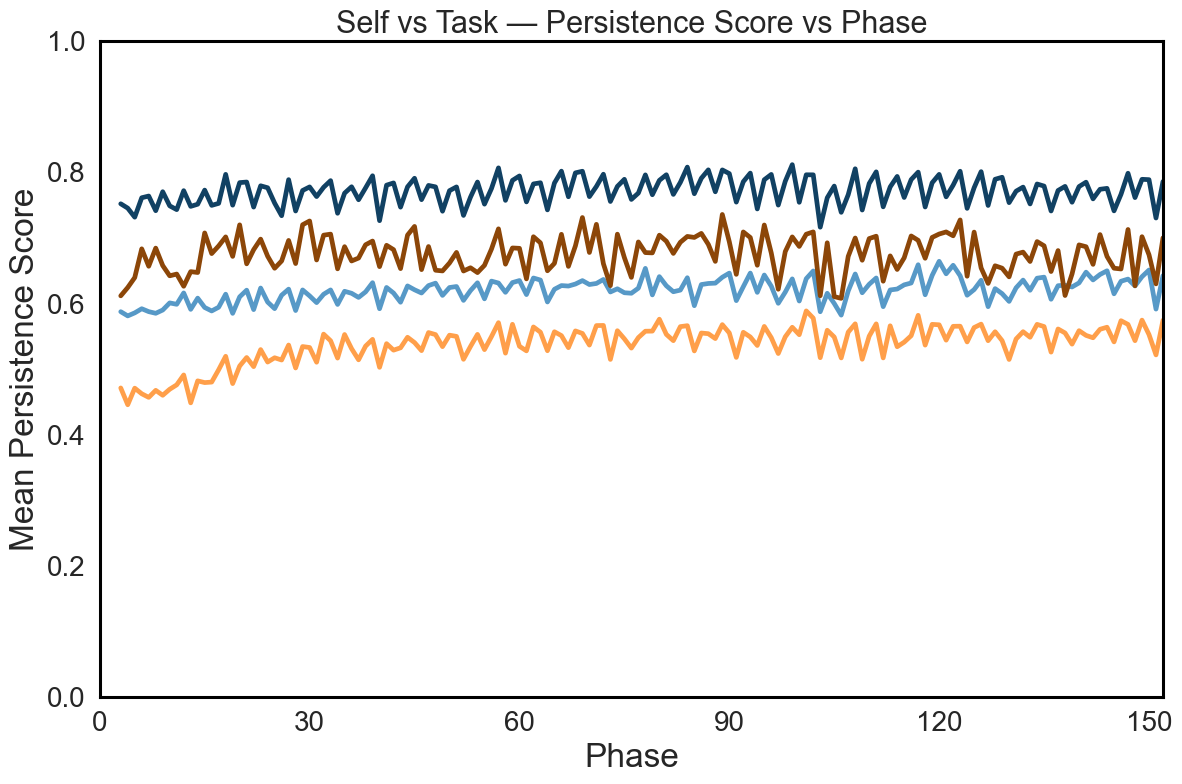

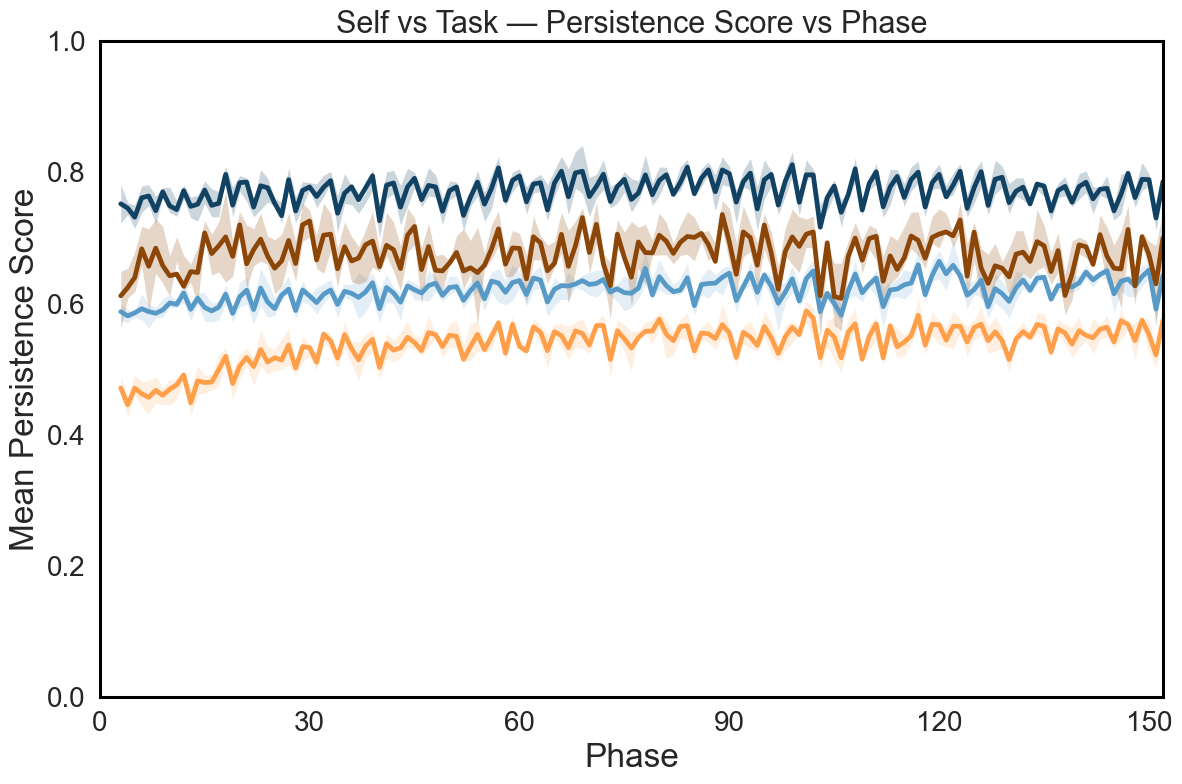

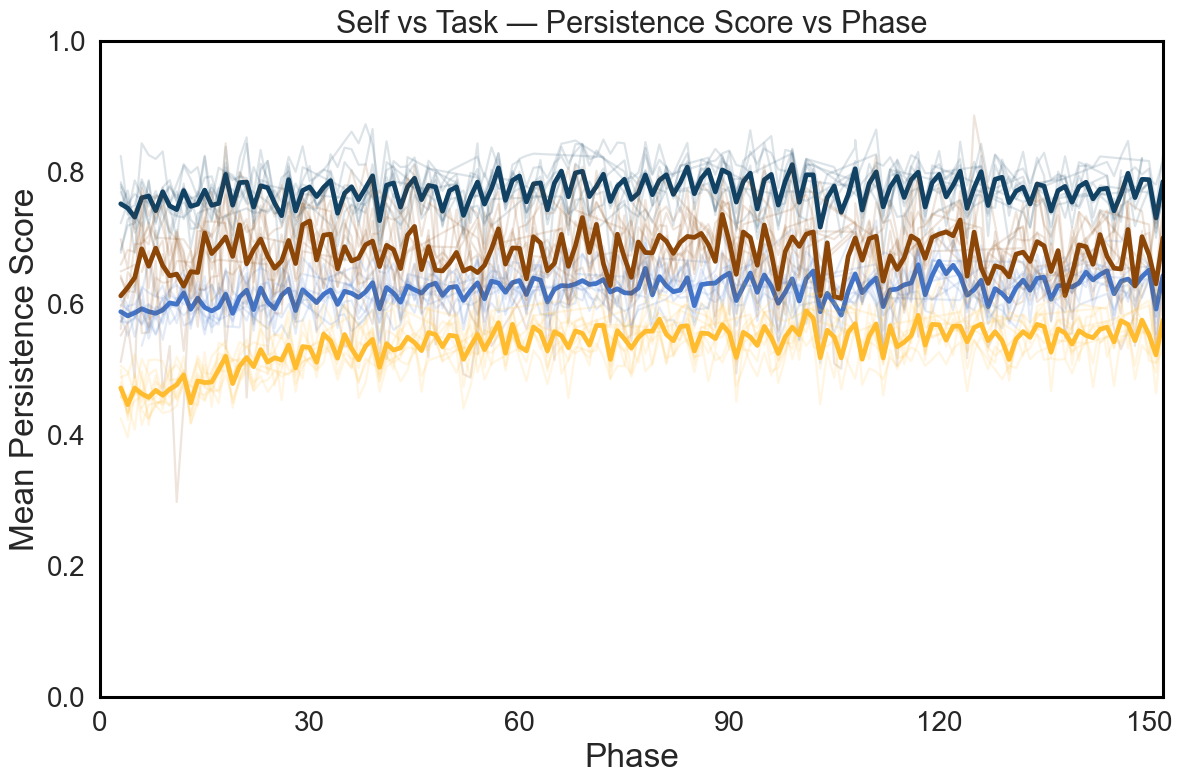

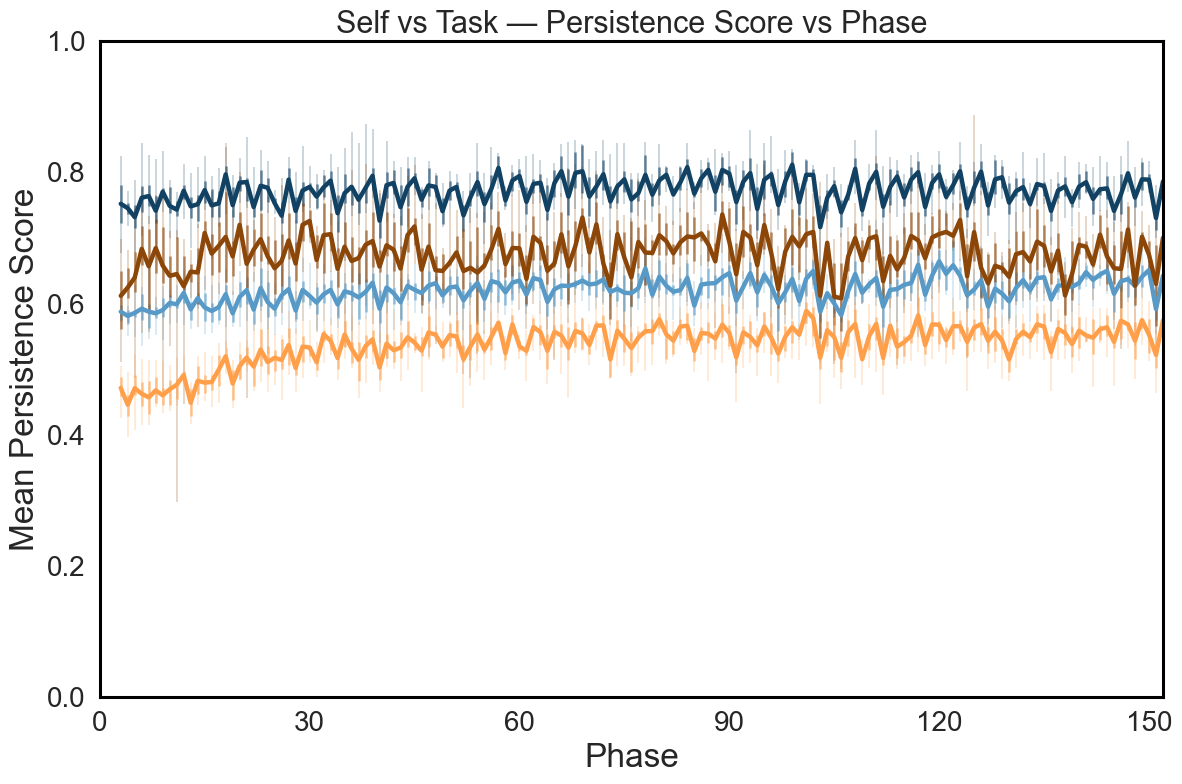

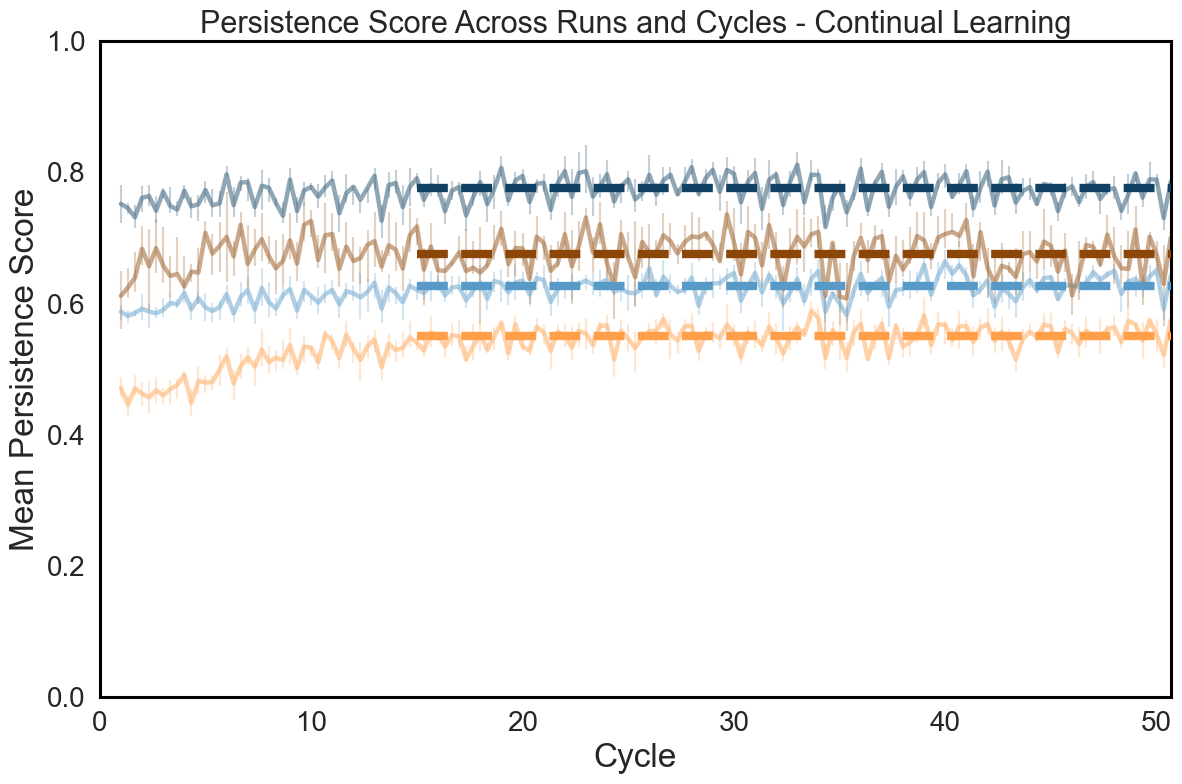

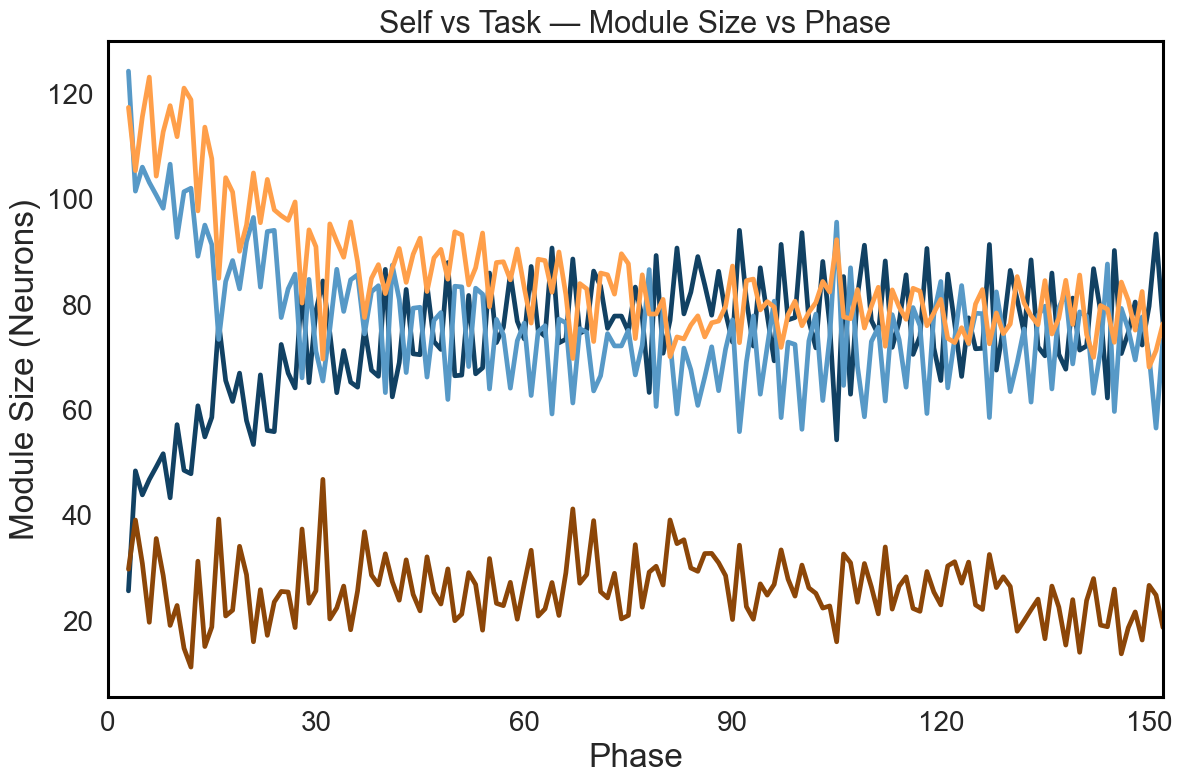

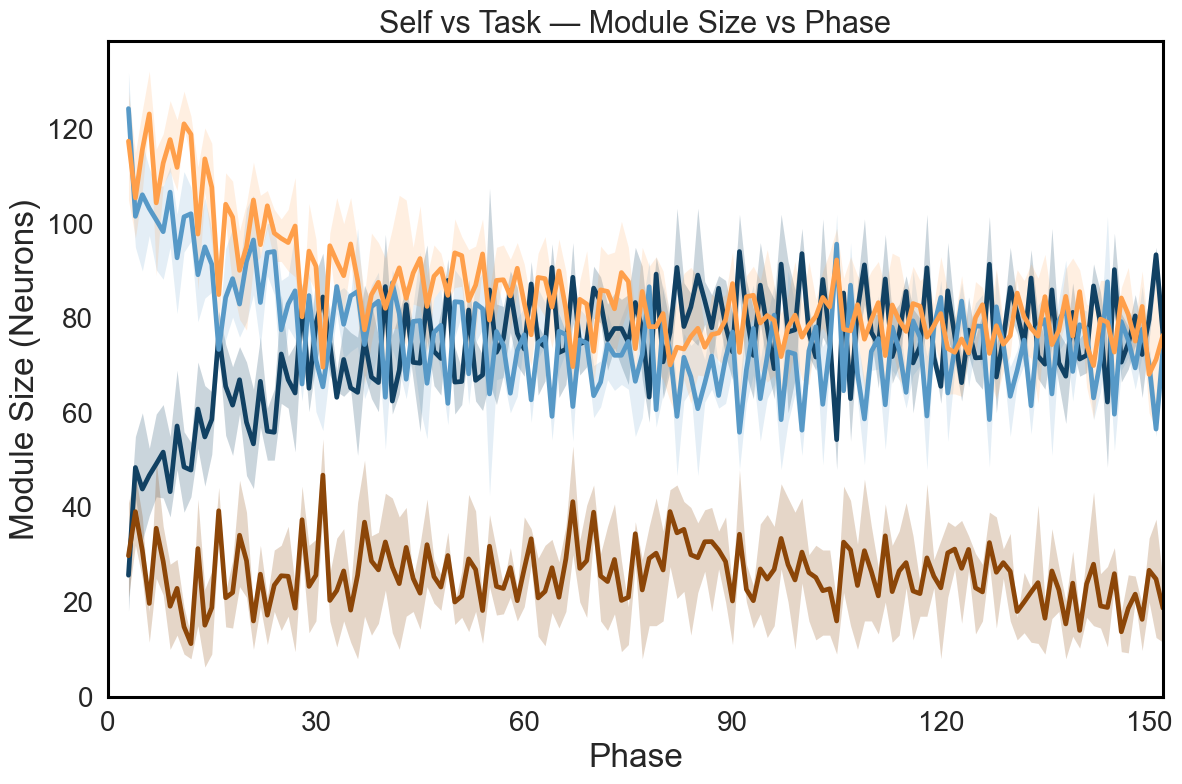

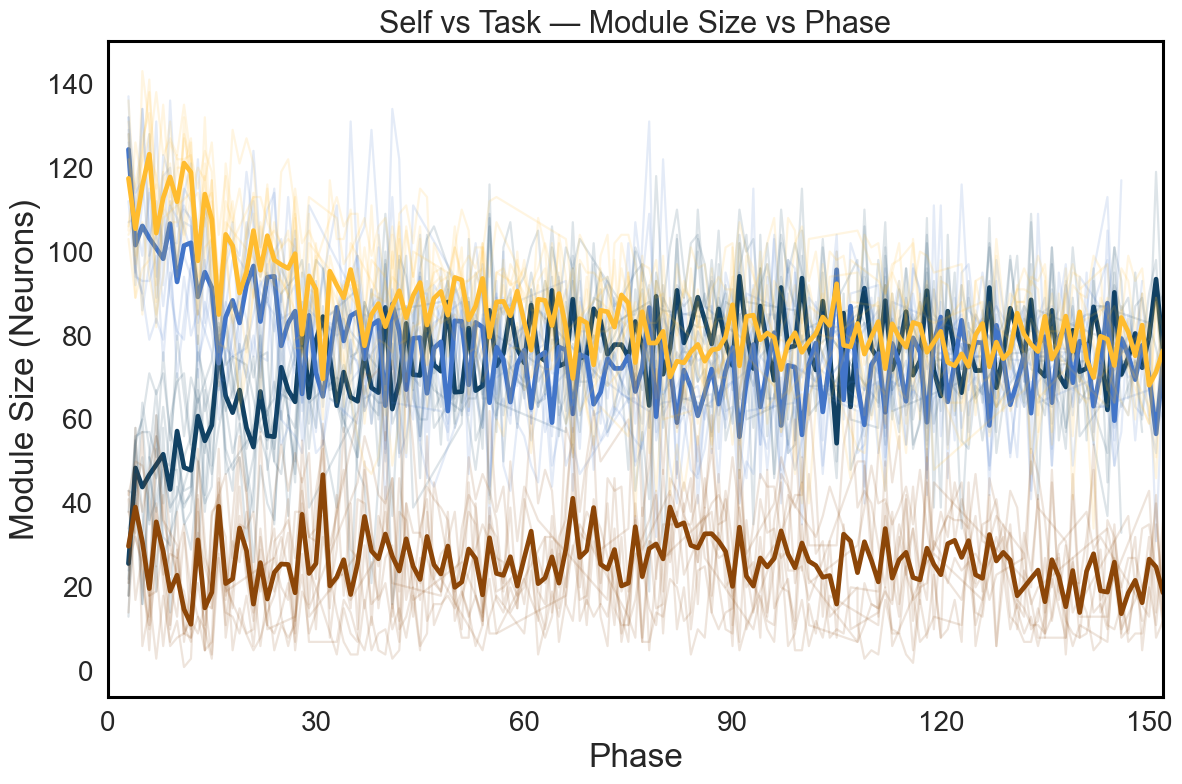

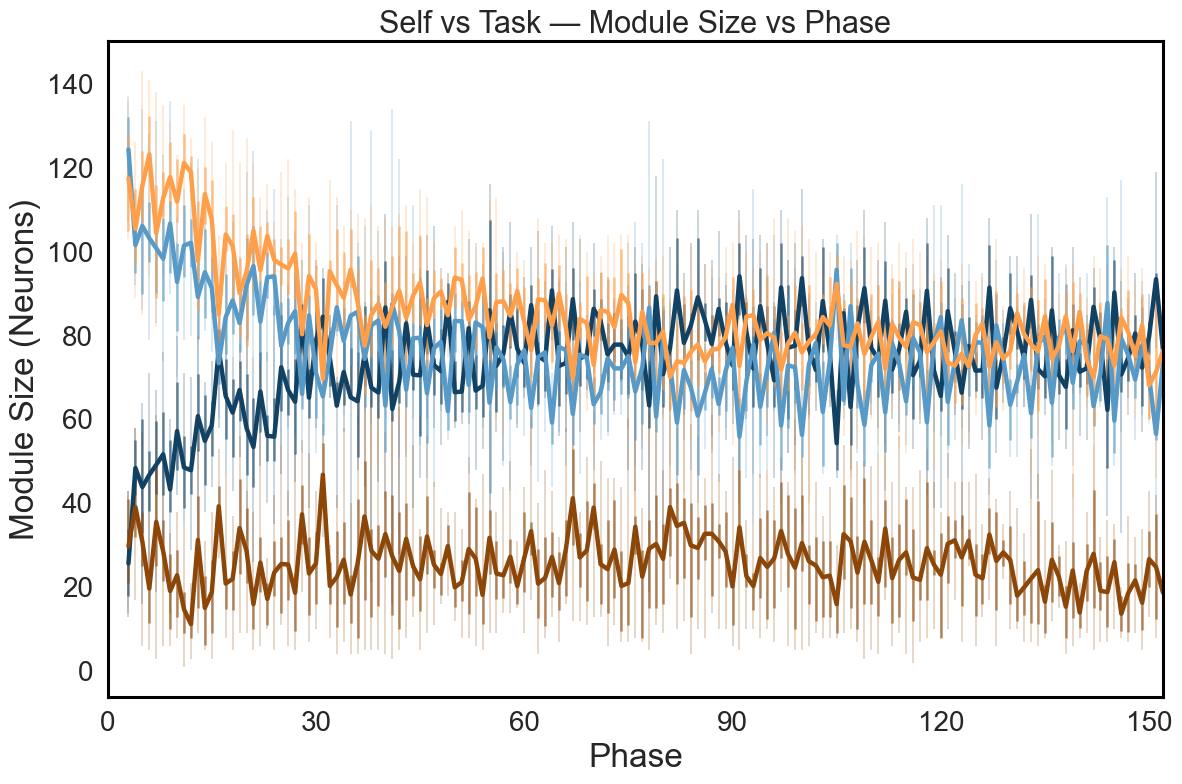

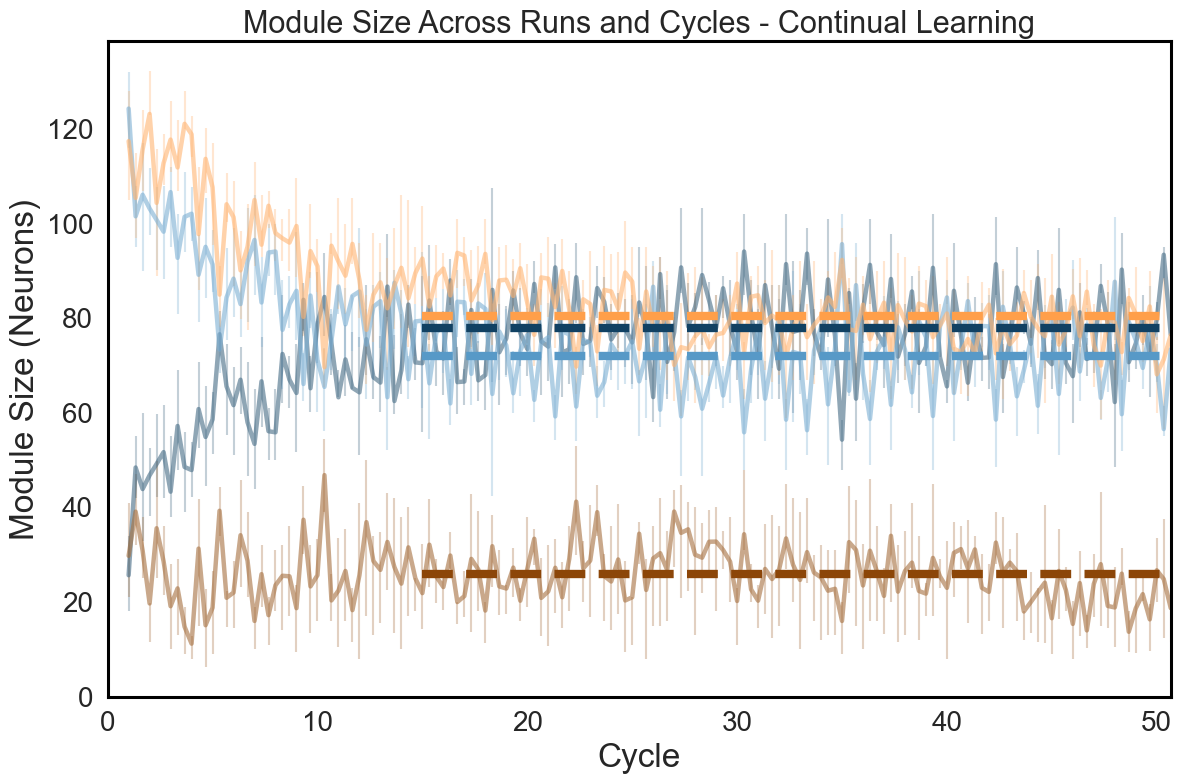

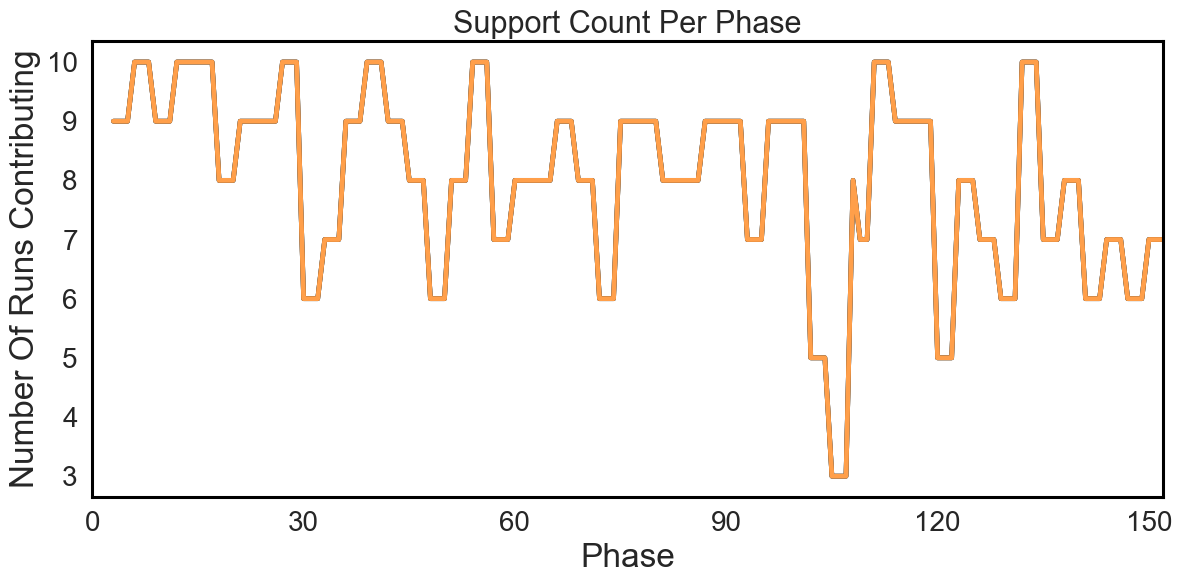

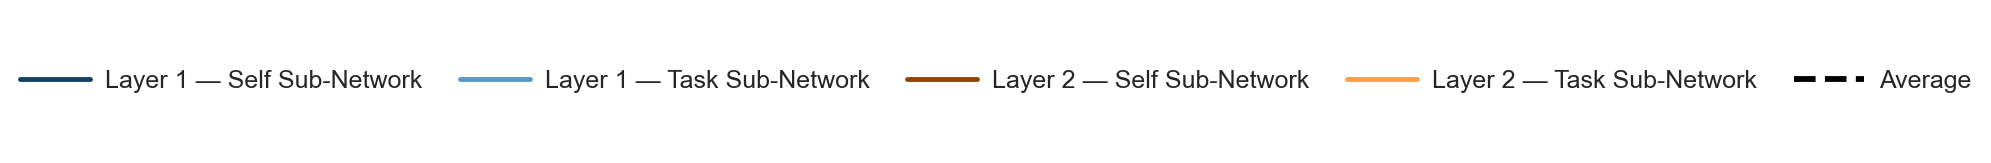

In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import EmptyDataError
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib as mpl

# ============================================================
# =============== MULTI-RUN AGGREGATE PLOTTING ===============
#   same plots as before
#   legends removed from plots
#   one separate horizontal legend figure added at the end
# ============================================================

# -------------------------
# CONFIG
# -------------------------
ROBUSTNESS_ROOT = "/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/WalkSpinJump_relu"

SHOW_SPREAD_PLOTS = True

MODULES_TO_PLOT = ["self", "task"]
LAYERS_TO_PLOT = None

BEHAVIORS = "auto"

Q_LOW  = 0.25
Q_HIGH = 0.75

N_CYCLES_PLANNED = None

FIGSIZE_MAIN = (12, 8)
FIGSIZE_SUPPORT = (12, 6)
FIGSIZE_LEGEND = (18, 1.8)

N_XTICKS_MAIN = 6

AXIS_LABEL_FONTSIZE = 24
TICK_LABEL_FONTSIZE = 20
TITLE_FONTSIZE = 22
LEGEND_FONTSIZE = 18

LINEWIDTH_MEAN = 3.4
LINEWIDTH_RUNS = 1.6
LINEWIDTH_ERROR_MEAN = 3.2

AXIS_SPINE_LINEWIDTH = 2.2
AXIS_SPINE_COLOR = "black"
TICK_WIDTH = 2.0
TICK_LENGTH = 7

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.sans-serif"] = ["Arial"]
sns.set_theme(style="white")
mpl.rcParams["axes.grid"] = False


# ============================================================
# Helpers
# ============================================================
def _find_phase_csvs(root: str):
    patterns = [
        os.path.join(root, "*", "models", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "*", "organized", "models", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "models", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "organized", "models", "_module_explorer_cache", "phase_summary.csv"),
        os.path.join(root, "phase_summary.csv"),
    ]
    out = []
    for pat in patterns:
        out.extend(glob.glob(pat))
    return sorted(set(out))


def _run_name_from_csv_path(csv_path: str) -> str:
    parts = os.path.normpath(csv_path).split(os.sep)
    root_base = os.path.basename(os.path.normpath(ROBUSTNESS_ROOT))
    try:
        idx = parts.index(root_base)
        return parts[idx + 1]
    except Exception:
        if "organized" in parts:
            return parts[parts.index("organized") - 1]
        if "models" in parts:
            return parts[parts.index("models") - 1]
        return os.path.basename(os.path.dirname(os.path.dirname(csv_path)))


def _safe_read_phase_csv(csv_path: str, min_bytes: int = 5):
    if not os.path.exists(csv_path):
        return None, "missing file"
    if os.path.getsize(csv_path) < min_bytes:
        return None, f"empty file (<{min_bytes} bytes)"
    try:
        df = pd.read_csv(csv_path)
    except EmptyDataError:
        return None, "EmptyDataError (no columns to parse)"
    except Exception as e:
        return None, f"read_csv failed: {type(e).__name__}: {e}"

    if df is None or df.shape[1] == 0:
        return None, "no columns after read"
    if len(df) == 0:
        return None, "valid header but 0 rows"

    required_cols = ["behavior", "layer_idx", "cluster_rank"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        return None, f"missing required cols: {missing}"

    return df, None


def _parse_cycle_num_from_cycle_id(cycle_id: str) -> int:
    m = re.search(r"(\d+)", str(cycle_id))
    return int(m.group(1)) if m else -1


def _ensure_cycle_num_column(df: pd.DataFrame) -> pd.DataFrame:
    if "cycle_num" in df.columns:
        out = df.copy()
        out["cycle_num"] = pd.to_numeric(out["cycle_num"], errors="coerce").fillna(-1).astype(int)
        return out
    if "cycle_idx" in df.columns:
        out = df.copy()
        out["cycle_num"] = pd.to_numeric(out["cycle_idx"], errors="coerce").fillna(-1).astype(int)
        return out
    if "cycle" in df.columns:
        out = df.copy()
        out["cycle_num"] = pd.to_numeric(out["cycle"], errors="coerce").fillna(-1).astype(int)
        return out
    if "cycle_id" in df.columns:
        out = df.copy()
        out["cycle_num"] = out["cycle_id"].apply(_parse_cycle_num_from_cycle_id).astype(int)
        return out
    if "step_idx" in df.columns:
        out = df.copy()
        step = pd.to_numeric(out["step_idx"], errors="coerce").fillna(-1).astype(int)
        out["cycle_num"] = step
        return out
    raise RuntimeError(
        "Could not determine cycle index. Expected one of: cycle_id / cycle_num / cycle_idx / cycle / step_idx."
    )


def _nanquantile_safe(x, q):
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(np.quantile(arr, q))


def _nanmin_safe(x):
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(np.min(arr))


def _nanmax_safe(x):
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    return float(np.max(arr))


def _n_finite(x):
    arr = np.asarray(x, dtype=float)
    return int(np.sum(np.isfinite(arr)))


def _agg_combined_step_module(dfp, col: str, Q_LOW=0.25, Q_HIGH=0.75):
    gcols = ["step_abs", "layer_idx", "module"]
    g = dfp.groupby(gcols)[col]
    out = g.agg(
        mean="mean",
        qlow=lambda x: _nanquantile_safe(x, Q_LOW),
        qhigh=lambda x: _nanquantile_safe(x, Q_HIGH),
        vmin=lambda x: _nanmin_safe(x),
        vmax=lambda x: _nanmax_safe(x),
        n=lambda x: _n_finite(x),
    ).reset_index()
    return out


def _make_dense_series_step_module(df_agg, layer_idx, module, which="mean", max_step_abs=0):
    sub = df_agg[
        (df_agg["layer_idx"] == layer_idx) &
        (df_agg["module"] == module)
    ][["step_abs", which]].sort_values("step_abs")

    x = np.arange(max_step_abs + 1, dtype=int)
    y = np.full_like(x, np.nan, dtype=float)

    if len(sub) == 0:
        return x, y

    idx = sub["step_abs"].to_numpy(dtype=int)
    vals = sub[which].to_numpy(dtype=float)
    m = (idx >= 0) & (idx < len(y))
    y[idx[m]] = vals[m]
    return x, y


# ============================================================
# Colors
# ============================================================
_LAYER_BASE = sns.color_palette("tab10", n_colors=10)

def _blend(rgb, other_rgb, t):
    rgb = np.array(rgb, dtype=float)
    other_rgb = np.array(other_rgb, dtype=float)
    out = (1.0 - t) * rgb + t * other_rgb
    return tuple(np.clip(out, 0, 1))

def _darken(rgb, t=0.35):
    return _blend(rgb, (0, 0, 0), t)

def _lighten(rgb, t=0.35):
    return _blend(rgb, (1, 1, 1), t)

def _color_module(module, layer_color_index):
    base = _LAYER_BASE[layer_color_index % 10]
    if str(module) == "self":
        return _darken(base, t=0.45)
    return _lighten(base, t=0.25)

def _color_module_runs(module, layer_color_index):
    base = np.array(_LAYER_BASE[layer_color_index % 10], dtype=float)
    hsv = rgb_to_hsv(base)
    if str(module) == "self":
        return _darken(tuple(base), t=0.45)
    hsv2 = hsv.copy()
    hsv2[0] = (hsv2[0] + 0.035) % 1.0
    hsv2[1] = min(1.0, hsv2[1] * 1.05)
    hsv2[2] = min(1.0, hsv2[2] * 1.05)
    rgb2 = tuple(hsv_to_rgb(hsv2))
    return _lighten(rgb2, t=0.18)


# ============================================================
# Legend labels
# ============================================================
def _layer_label(layer_idx: int) -> str:
    return f"Layer {int(layer_idx) + 1}"

def _module_label(module: str) -> str:
    m = str(module).strip().lower()
    if m == "self":
        return "Self Sub-Network"
    if m == "task":
        return "Task Sub-Network"
    return m

def _legend_label(layer_idx: int, module: str) -> str:
    return f"{_layer_label(layer_idx)} — {_module_label(module)}"


# ============================================================
# Axis formatting
# ============================================================
def _format_axes_paper(ax, xmin, xmax, n_xticks):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_SPINE_LINEWIDTH)
        spine.set_color(AXIS_SPINE_COLOR)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_FONTSIZE,
        width=TICK_WIDTH,
        length=TICK_LENGTH,
        color=AXIS_SPINE_COLOR,
    )

    ax.margins(x=0)
    ax.set_xlim(xmin, xmax)
    try:
        ax.set_xbound(lower=xmin, upper=xmax)
    except Exception:
        pass
    ax.xaxis.set_major_locator(MaxNLocator(n_xticks, integer=True))

def _raise_title(ax):
    ax.title.set_y(1.03)


# ============================================================
# Separate legend figure
# ============================================================
def _make_horizontal_legend_figure(include_average=True):
    handles = []
    labels = []

    for i, L in enumerate(layers_to_plot):
        for module in MODULES_TO_PLOT:
            c = _color_module(module, i)
            handles.append(Line2D([0], [0], color=c, linewidth=3.5))
            labels.append(_legend_label(L, module))

    if include_average:
        handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=4.2))
        labels.append("Average")

    fig, ax = plt.subplots(figsize=FIGSIZE_LEGEND)
    ax.axis("off")
    ax.legend(
        handles,
        labels,
        loc="center",
        ncol=len(labels),
        frameon=False,
        fontsize=LEGEND_FONTSIZE,
        handlelength=2.8,
        columnspacing=1.5,
        handletextpad=0.6,
    )
    plt.tight_layout()
    plt.show()


# ============================================================
# Load data
# ============================================================
phase_csvs = _find_phase_csvs(ROBUSTNESS_ROOT)
if not phase_csvs:
    raise FileNotFoundError(f"No phase_summary.csv found under: {ROBUSTNESS_ROOT}")

dfs = []
skipped = []
for csv_path in phase_csvs:
    run_name = _run_name_from_csv_path(csv_path)
    df, reason = _safe_read_phase_csv(csv_path)
    if df is None:
        skipped.append((run_name, csv_path, reason))
        continue

    df = df.copy()
    df["run_name"] = run_name
    try:
        df = _ensure_cycle_num_column(df)
    except Exception as e:
        skipped.append((run_name, csv_path, f"cycle inference failed: {type(e).__name__}: {e}"))
        continue

    dfs.append(df)

print(f"[INFO] Found {len(phase_csvs)} phase_summary.csv files")
print(f"[INFO] Loaded {len(dfs)} runs successfully")
print(f"[INFO] Skipped {len(skipped)} runs")

if skipped:
    print("\n[SKIPPED RUNS]")
    for rn, p, why in skipped:
        print(f"  - {rn}: {why}\n    {p}")

if not dfs:
    raise RuntimeError("No valid runs loaded (all phase_summary.csv were empty/invalid).")

df_all = pd.concat(dfs, ignore_index=True)

dfp = df_all.copy()
dfp["behavior"] = dfp["behavior"].astype(str).str.strip().str.lower()

_PREF_ORDER = ["walk", "jump", "spin"]
present = [b for b in _PREF_ORDER if b in set(dfp["behavior"].unique().tolist())]

if BEHAVIORS == "auto":
    if not present:
        present = sorted(set(dfp["behavior"].unique().tolist()))
        if not present:
            raise RuntimeError("No behaviors found in data.")
    BEH_USED = present
else:
    BEH_USED = [str(b).strip().lower() for b in list(BEHAVIORS)]
    BEH_USED = [b for b in BEH_USED if b in set(dfp["behavior"].unique().tolist())]
    if not BEH_USED:
        raise RuntimeError(f"Requested BEHAVIORS={BEHAVIORS} but none are present in the data.")

dfp = dfp[dfp["behavior"].isin(BEH_USED)].copy()

for c in ["layer_idx", "cluster_rank"]:
    dfp[c] = pd.to_numeric(dfp[c], errors="coerce").fillna(-1).astype(int)

if "mean_persistence_score" in dfp.columns:
    SCORE_COL = "mean_persistence_score"
elif "mean_self_score" in dfp.columns:
    SCORE_COL = "mean_self_score"
elif "mean_persistence" in dfp.columns:
    SCORE_COL = "mean_persistence"
else:
    raise KeyError(
        "Missing score column. Expected one of: mean_persistence_score / mean_self_score / mean_persistence."
    )
dfp[SCORE_COL] = pd.to_numeric(dfp[SCORE_COL], errors="coerce")

if "cluster_size_neurons" not in dfp.columns:
    raise KeyError("Missing cluster_size_neurons in CSV; needed to define self/task modules.")
dfp["cluster_size_neurons"] = pd.to_numeric(dfp["cluster_size_neurons"], errors="coerce").fillna(0).astype(float)

# ============================================================
# Build module-level dataframe
# ============================================================
df_self = dfp[dfp["cluster_rank"] == 1].copy()
if len(df_self) == 0:
    raise RuntimeError("No cluster_rank==1 rows found; cannot define self module.")

df_self["module"] = "self"
df_self_mod = df_self.copy()

df_other = dfp[dfp["cluster_rank"] >= 2].copy()
df_other["w"] = df_other["cluster_size_neurons"] * df_other[SCORE_COL]

group_keys = ["run_name", "behavior", "cycle_num", "layer_idx"]

task_agg = df_other.groupby(group_keys, as_index=False).agg(
    other_size_sum=("cluster_size_neurons", "sum"),
    w_sum=("w", "sum"),
)

task_agg["module"] = "task"
task_agg[SCORE_COL] = task_agg["w_sum"] / task_agg["other_size_sum"].replace(0, np.nan)
task_agg["cluster_size_neurons"] = task_agg["other_size_sum"]

if "n_alive_units" in df_self_mod.columns:
    alive_info = df_self_mod[group_keys + ["n_alive_units", "cluster_size_neurons"]].copy()
    alive_info = alive_info.rename(columns={
        "cluster_size_neurons": "self_size",
        "n_alive_units": "n_alive_units",
    })
    alive_info["n_alive_units"] = pd.to_numeric(alive_info["n_alive_units"], errors="coerce")
    alive_info["self_size"] = pd.to_numeric(alive_info["self_size"], errors="coerce")

    task_agg = task_agg.merge(alive_info, on=group_keys, how="left")
    task_agg["cluster_size_neurons"] = (task_agg["n_alive_units"] - task_agg["self_size"]).clip(lower=0)

task_rows = task_agg[group_keys + ["module", "cluster_size_neurons", SCORE_COL]].copy()

dfm = pd.concat(
    [
        df_self_mod[group_keys + ["module", "cluster_size_neurons", SCORE_COL]].copy(),
        task_rows.copy(),
    ],
    ignore_index=True
)

dfm["module"] = dfm["module"].astype(str).str.strip().str.lower()
dfm = dfm[dfm["module"].isin([m.lower() for m in MODULES_TO_PLOT])].copy()

if LAYERS_TO_PLOT is None:
    layers_to_plot = sorted(dfm["layer_idx"].unique().tolist())
else:
    layers_to_plot = list(LAYERS_TO_PLOT)

if not layers_to_plot:
    raise RuntimeError("No layers found after building self/task modules.")

beh_to_idx = {b: i for i, b in enumerate(BEH_USED)}
dfm["beh_idx"] = dfm["behavior"].map(beh_to_idx).astype(int)

N_BEH_USED = len(BEH_USED)

# -------------------------
# MINIMAL CHANGE: for any single-behavior run (walk-only OR jump-only OR spin-only),
# keep the x-axis comparable to WSJ by using 3 phases-per-cycle for the cycle plot.
# -------------------------
if N_BEH_USED == 1:
    PLOT4_PHASES_PER_CYCLE = 3
else:
    PLOT4_PHASES_PER_CYCLE = N_BEH_USED

if N_CYCLES_PLANNED is not None:
    dfm = dfm[(dfm["cycle_num"] >= 0) & (dfm["cycle_num"] < int(N_CYCLES_PLANNED))].copy()
else:
    dfm = dfm[dfm["cycle_num"] >= 0].copy()

dfm["step_abs"] = dfm["cycle_num"] * N_BEH_USED + dfm["beh_idx"]

if len(dfm) == 0:
    raise RuntimeError("No rows left after filtering; check cycle_num / behavior filters.")
MAX_STEP_ABS = int(dfm["step_abs"].max())

grp = dfm.groupby(["run_name", "cycle_num", "layer_idx", "module"])["behavior"].nunique()
valid_keys = grp[grp == N_BEH_USED].index
valid_df = valid_keys.to_frame(index=False)

dfm = dfm.merge(
    valid_df,
    on=["run_name", "cycle_num", "layer_idx", "module"],
    how="inner"
).copy()

if len(dfm) == 0:
    raise RuntimeError("All cycles dropped as incomplete; adjust BEHAVIORS or check the CSV content.")
MAX_STEP_ABS = int(dfm["step_abs"].max())

print(f"[INFO] Behaviors used: {BEH_USED}  (N_BEH_USED={N_BEH_USED})")
print(f"[INFO] Plot-4 phases-per-cycle: {PLOT4_PHASES_PER_CYCLE}")
print(f"[INFO] Max phase index (MAX_STEP_ABS): {MAX_STEP_ABS}  -> phases plotted: {MAX_STEP_ABS + 1}")
print(f"[INFO] Rows after dropping incomplete cycles: {len(dfm)}")


def _cycle_plot_title(metric_name: str):
    if N_BEH_USED == 1:
        return f"{metric_name} Across Runs and Cycles - Single Task"
    return f"{metric_name} Across Runs and Cycles - Continual Learning"


# ============================================================
# Plots
# ============================================================
def _plot_combined_timeline(df_agg, col_name, ylabel, title, with_spread=False, ylim=None):
    plt.figure(figsize=FIGSIZE_MAIN)
    ax = plt.gca()

    for i, L in enumerate(layers_to_plot):
        for module in MODULES_TO_PLOT:
            module = str(module).strip().lower()
            color = _color_module(module, i)
            x, y_mean = _make_dense_series_step_module(df_agg, L, module, which="mean", max_step_abs=MAX_STEP_ABS)
            m = np.isfinite(y_mean)
            if not np.any(m):
                continue

            ax.plot(x[m], y_mean[m], color=color, alpha=1.0, linewidth=LINEWIDTH_MEAN)

            if with_spread:
                _, y_lo = _make_dense_series_step_module(df_agg, L, module, which="qlow", max_step_abs=MAX_STEP_ABS)
                _, y_hi = _make_dense_series_step_module(df_agg, L, module, which="qhigh", max_step_abs=MAX_STEP_ABS)
                m2 = np.isfinite(y_lo) & np.isfinite(y_hi)
                ax.fill_between(
                    x[m2], y_lo[m2], y_hi[m2],
                    color=color,
                    alpha=0.22 if module == "self" else 0.16,
                    linewidth=0
                )

    ax.set_xlabel("Phase", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    _raise_title(ax)
    if ylim is not None:
        ax.set_ylim(*ylim)

    _format_axes_paper(ax, 0, MAX_STEP_ABS, N_XTICKS_MAIN)
    plt.tight_layout()
    plt.show()


def _plot_combined_timeline_all_runs(df_agg, col_name, ylabel, title, ylim=None):
    plt.figure(figsize=FIGSIZE_MAIN)
    ax = plt.gca()

    run_names = sorted(dfm["run_name"].unique().tolist())
    run_alpha = 0.14
    mean_lw = LINEWIDTH_MEAN

    for i, L in enumerate(layers_to_plot):
        for module in MODULES_TO_PLOT:
            module = str(module).strip().lower()
            color = _color_module_runs(module, i)

            for rn in run_names:
                sub = dfm[
                    (dfm["run_name"] == rn) &
                    (dfm["layer_idx"] == L) &
                    (dfm["module"] == module)
                ][["step_abs", col_name]].sort_values("step_abs")

                if len(sub) == 0:
                    continue

                x = sub["step_abs"].to_numpy(dtype=int)
                y = sub[col_name].to_numpy(dtype=float)
                m = np.isfinite(x) & np.isfinite(y)
                if np.any(m):
                    ax.plot(x[m], y[m], color=color, alpha=run_alpha, linewidth=LINEWIDTH_RUNS)

            x, y_mean = _make_dense_series_step_module(df_agg, L, module, which="mean", max_step_abs=MAX_STEP_ABS)
            m = np.isfinite(y_mean)
            if np.any(m):
                ax.plot(x[m], y_mean[m], color=color, alpha=1.0, linewidth=mean_lw)

    ax.set_xlabel("Phase", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    _raise_title(ax)
    if ylim is not None:
        ax.set_ylim(*ylim)

    _format_axes_paper(ax, 0, MAX_STEP_ABS, N_XTICKS_MAIN)
    plt.tight_layout()
    plt.show()


def _plot_combined_timeline_errorbars(df_agg, col_name, ylabel, title, ylim=None):
    plt.figure(figsize=FIGSIZE_MAIN)
    ax = plt.gca()

    for i, L in enumerate(layers_to_plot):
        for module in MODULES_TO_PLOT:
            module = str(module).strip().lower()
            color = _color_module(module, i)

            x, y_mean = _make_dense_series_step_module(df_agg, L, module, which="mean", max_step_abs=MAX_STEP_ABS)
            _, y_lo = _make_dense_series_step_module(df_agg, L, module, which="qlow", max_step_abs=MAX_STEP_ABS)
            _, y_hi = _make_dense_series_step_module(df_agg, L, module, which="qhigh", max_step_abs=MAX_STEP_ABS)
            _, y_min = _make_dense_series_step_module(df_agg, L, module, which="vmin", max_step_abs=MAX_STEP_ABS)
            _, y_max = _make_dense_series_step_module(df_agg, L, module, which="vmax", max_step_abs=MAX_STEP_ABS)

            m = np.isfinite(y_mean)
            if not np.any(m):
                continue

            ax.plot(x[m], y_mean[m], color=color, alpha=1.0, linewidth=LINEWIDTH_ERROR_MEAN)

            m_iqr = m & np.isfinite(y_lo) & np.isfinite(y_hi)
            if np.any(m_iqr):
                lo = np.clip(y_mean[m_iqr] - y_lo[m_iqr], 0.0, np.inf)
                hi = np.clip(y_hi[m_iqr] - y_mean[m_iqr], 0.0, np.inf)
                ax.errorbar(
                    x[m_iqr], y_mean[m_iqr],
                    yerr=[lo, hi],
                    fmt="none",
                    ecolor=color,
                    elinewidth=1.8,
                    capsize=0,
                    alpha=0.60,
                    zorder=1
                )

            m_rng = m & np.isfinite(y_min) & np.isfinite(y_max)
            if np.any(m_rng):
                lo = np.clip(y_mean[m_rng] - y_min[m_rng], 0.0, np.inf)
                hi = np.clip(y_max[m_rng] - y_mean[m_rng], 0.0, np.inf)
                ax.errorbar(
                    x[m_rng], y_mean[m_rng],
                    yerr=[lo, hi],
                    fmt="none",
                    ecolor=color,
                    elinewidth=1.1,
                    capsize=0,
                    alpha=0.28,
                    zorder=0
                )

    ax.set_xlabel("Phase", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    _raise_title(ax)
    if ylim is not None:
        ax.set_ylim(*ylim)

    _format_axes_paper(ax, 0, MAX_STEP_ABS, N_XTICKS_MAIN)
    plt.tight_layout()
    plt.show()


def _plot_cycle_timeline_iqr_with_avgline(
    df_step_agg,
    ylabel,
    title,
    ylim=None,
    dashed_start_cycle=15
):
    plt.figure(figsize=FIGSIZE_MAIN)
    ax = plt.gca()

    max_x_cycle = MAX_STEP_ABS / max(PLOT4_PHASES_PER_CYCLE, 1)

    for i, L in enumerate(layers_to_plot):
        for module in MODULES_TO_PLOT:
            module = str(module).strip().lower()

            base_color = _color_module(module, i)
            color_main = _lighten(base_color, t=0.22)

            x_phase, y_mean = _make_dense_series_step_module(
                df_step_agg, L, module, which="mean", max_step_abs=MAX_STEP_ABS
            )
            _, y_lo = _make_dense_series_step_module(
                df_step_agg, L, module, which="qlow", max_step_abs=MAX_STEP_ABS
            )
            _, y_hi = _make_dense_series_step_module(
                df_step_agg, L, module, which="qhigh", max_step_abs=MAX_STEP_ABS
            )

            x_cycle = x_phase.astype(float) / max(PLOT4_PHASES_PER_CYCLE, 1)

            m = np.isfinite(y_mean)
            if not np.any(m):
                continue

            ax.plot(
                x_cycle[m], y_mean[m],
                color=color_main,
                alpha=0.60,
                linewidth=LINEWIDTH_ERROR_MEAN,
                zorder=2
            )

            m_iqr = m & np.isfinite(y_lo) & np.isfinite(y_hi)
            if np.any(m_iqr):
                lo = np.clip(y_mean[m_iqr] - y_lo[m_iqr], 0.0, np.inf)
                hi = np.clip(y_hi[m_iqr] - y_mean[m_iqr], 0.0, np.inf)
                ax.errorbar(
                    x_cycle[m_iqr], y_mean[m_iqr],
                    yerr=[lo, hi],
                    fmt="none",
                    ecolor=color_main,
                    elinewidth=1.5,
                    capsize=0,
                    alpha=0.32,
                    zorder=1
                )

            if max_x_cycle >= dashed_start_cycle:
                m_avg = m & (x_cycle >= dashed_start_cycle)
                avg_line = np.nanmean(y_mean[m_avg]) if np.any(m_avg) else np.nan
                if np.isfinite(avg_line):
                    x_avg = np.array([dashed_start_cycle, max_x_cycle], dtype=float)
                    y_avg = np.array([avg_line, avg_line], dtype=float)
                    ax.plot(
                        x_avg, y_avg,
                        linestyle="--",
                        linewidth=6,
                        color=base_color,
                        alpha=1.0,
                        zorder=3
                    )

    ax.set_xlabel("Cycle", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    _raise_title(ax)

    if ylim is not None:
        ax.set_ylim(*ylim)

    _format_axes_paper(ax, 0, max_x_cycle, N_XTICKS_MAIN)

    tick_max = int(np.floor(max_x_cycle))
    xticks = np.arange(0, tick_max + 1, 10, dtype=int)
    if len(xticks) == 0:
        xticks = np.array([0], dtype=int)
    if xticks[-1] != tick_max:
        xticks = np.append(xticks, tick_max)

    ax.set_xticks(xticks.astype(float))
    ax.set_xticklabels([str(int(t)) for t in xticks], fontsize=TICK_LABEL_FONTSIZE)

    plt.tight_layout()
    plt.show()


def _plot_support_counts(df_agg_counts, title):
    plt.figure(figsize=FIGSIZE_SUPPORT)
    ax = plt.gca()

    for i, L in enumerate(layers_to_plot):
        for module in MODULES_TO_PLOT:
            module = str(module).strip().lower()
            color = _color_module(module, i)
            x, y = _make_dense_series_step_module(df_agg_counts, L, module, which="n", max_step_abs=MAX_STEP_ABS)
            m = np.isfinite(y)
            if not np.any(m):
                continue

            ax.plot(x[m], y[m], color=color, alpha=1.0, linewidth=LINEWIDTH_MEAN)

    ax.set_xlabel("Phase", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel("Number Of Runs Contributing", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    _raise_title(ax)

    _format_axes_paper(ax, 0, MAX_STEP_ABS, N_XTICKS_MAIN)
    plt.tight_layout()
    plt.show()


# ============================================================
# Run plots
# ============================================================
df_persist_step = _agg_combined_step_module(dfm, SCORE_COL, Q_LOW=Q_LOW, Q_HIGH=Q_HIGH)

_plot_combined_timeline(
    df_persist_step,
    SCORE_COL,
    "Mean Persistence Score",
    "Self vs Task — Persistence Score vs Phase",
    with_spread=False,
    ylim=(0, 1),
)

if SHOW_SPREAD_PLOTS:
    _plot_combined_timeline(
        df_persist_step,
        SCORE_COL,
        "Mean Persistence Score",
        "Self vs Task — Persistence Score vs Phase",
        with_spread=True,
        ylim=(0, 1),
    )

_plot_combined_timeline_all_runs(
    df_persist_step,
    SCORE_COL,
    "Mean Persistence Score",
    "Self vs Task — Persistence Score vs Phase",
    ylim=(0, 1),
)

_plot_combined_timeline_errorbars(
    df_persist_step,
    SCORE_COL,
    "Mean Persistence Score",
    "Self vs Task — Persistence Score vs Phase",
    ylim=(0, 1),
)

_plot_cycle_timeline_iqr_with_avgline(
    df_persist_step,
    "Mean Persistence Score",
    _cycle_plot_title("Persistence Score"),
    ylim=(0, 1),
    dashed_start_cycle=15
)

df_size_step = _agg_combined_step_module(dfm, "cluster_size_neurons", Q_LOW=Q_LOW, Q_HIGH=Q_HIGH)

_plot_combined_timeline(
    df_size_step,
    "cluster_size_neurons",
    "Module Size (Neurons)",
    "Self vs Task — Module Size vs Phase",
    with_spread=False,
    ylim=None,
)

if SHOW_SPREAD_PLOTS:
    _plot_combined_timeline(
        df_size_step,
        "cluster_size_neurons",
        "Module Size (Neurons)",
        "Self vs Task — Module Size vs Phase",
        with_spread=True,
        ylim=None,
    )

_plot_combined_timeline_all_runs(
    df_size_step,
    "cluster_size_neurons",
    "Module Size (Neurons)",
    "Self vs Task — Module Size vs Phase",
    ylim=None,
)

_plot_combined_timeline_errorbars(
    df_size_step,
    "cluster_size_neurons",
    "Module Size (Neurons)",
    "Self vs Task — Module Size vs Phase",
    ylim=None,
)

_plot_cycle_timeline_iqr_with_avgline(
    df_size_step,
    "Module Size (Neurons)",
    _cycle_plot_title("Module Size"),
    ylim=None,
    dashed_start_cycle=15
)

_plot_support_counts(df_persist_step, "Support Count Per Phase")

# separate horizontal legend figure
_make_horizontal_legend_figure(include_average=True)